<a href="https://colab.research.google.com/github/Prakat-star/FDS/blob/main/lab4_and_lab_5_bct024_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import random
from faker import Faker

fake = Faker()

np.random.seed(42)
random.seed(42)

n = 100

data = {
    'Date': [fake.date_this_decade() if random.random() > 0.1 else None for _ in range(n)],
    'CustomerID': [random.randint(1000, 9999) if random.random() > 0.05 else None for _ in range(n)],
    'Product': [random.choice(['Laptop', 'Phone', 'Tablet', 'Monitor', 'Keyboard', 'Headphones', 'Mouse']) for _ in range(n)],
    'Category': [random.choice(['Electronics', 'Furniture', 'Toys', 'Clothing', 'Sports']) for _ in range(n)],
    'Sales': [round(random.uniform(50, 1500), 2) if random.random() > 0.1 else None for _ in range(n)],
}

df = pd.DataFrame(data)

df['Product'] = df['Product'].where(np.random.random(len(df)) > 0.1, None)

df = pd.concat([df, df.sample(frac=0.05, random_state=42)], ignore_index=True)

df.to_csv('sales_data.csv', index=False)

print(df.head())
print(df.info())

         Date  CustomerID     Product     Category    Sales
0  2022-04-09         NaN      Laptop  Electronics  1297.64
1        None      9797.0  Headphones         Toys  1178.71
2  2021-04-09      6573.0     Monitor         Toys  1215.96
3  2022-01-10      8123.0       Mouse       Sports   723.60
4  2021-11-03      1053.0      Tablet     Clothing  1380.33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        91 non-null     object 
 1   CustomerID  100 non-null    float64
 2   Product     91 non-null     object 
 3   Category    105 non-null    object 
 4   Sales       97 non-null     float64
dtypes: float64(2), object(3)
memory usage: 4.2+ KB
None


In [ ]:
import pandas as pd

# Load the dataset (replace 'sales_data.csv' with your actual file path)
df = pd.read_csv('sales_data.csv')

# Check the first few rows of the dataset
df.head()

,Date,CustomerID,Product,Category,Sales
0,2022-04-09,NaN,Laptop,Electronics,1297.64
1,NaN,9797.0,Headphones,Toys,1178.71
2,2021-04-09,6573.0,Monitor,Toys,1215.96
3,2022-01-10,8123.0,Mouse,Sports,723.60
4,2021-11-03,1053.0,Tablet,Clothing,1380.33


In [ ]:
# Check for missing values in the dataset
print(df.isnull().sum())

# Option 1: Fill missing values (e.g., with the median for numerical columns)
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

# Option 2: Drop rows with missing values
df = df.dropna() # Drop rows with any missing values

Date          14
CustomerID     5
Product       14
Category       0
Sales          8
dtype: int64


In [ ]:
# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Convert 'Category' column to categorical type
df['Category'] = df['Category'].astype('category')

In [ ]:
# Remove duplicates based on all columns
df = df.drop_duplicates()

# Remove duplicates based on specific columns
df = df.drop_duplicates(subset=['CustomerID', 'Product'])

In [ ]:
# Extract the year and month from the 'Date' column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the 'Sales' column to be between 0 and 1
scaler = MinMaxScaler()
df['Sales_scaled'] = scaler.fit_transform(df[['Sales']])

In [ ]:
# Save the cleaned data to a new CSV file
df.to_csv('cleaned_sales_data.csv', index=False)

In [ ]:
# Get a summary of numerical columns
df.describe()

# Get summary statistics for categorical columns
df['Category'].value_counts()

,count
Category,
Sports,18
Clothing,17
Toys,13
Furniture,12
Electronics,11


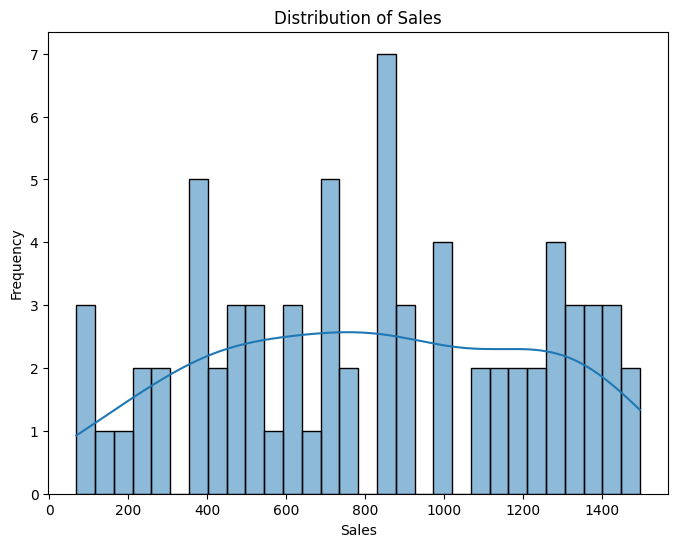

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a histogram of 'Sales'
plt.figure(figsize=(8, 6))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

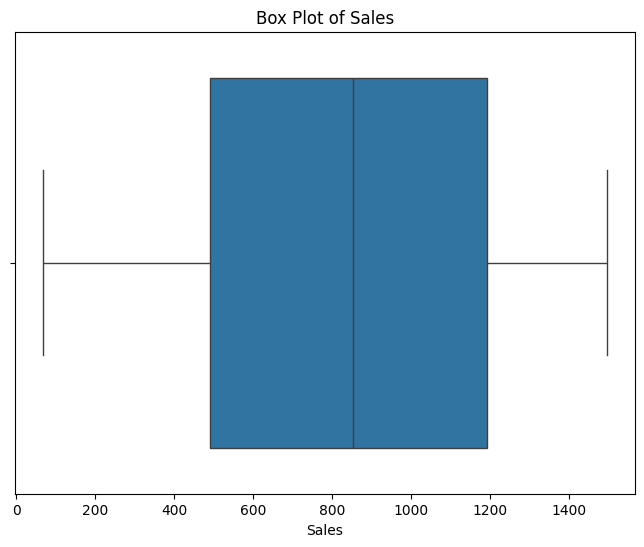

In [ ]:
# Box plot for 'Sales'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Sales'])
plt.title('Box Plot of Sales')
plt.show()

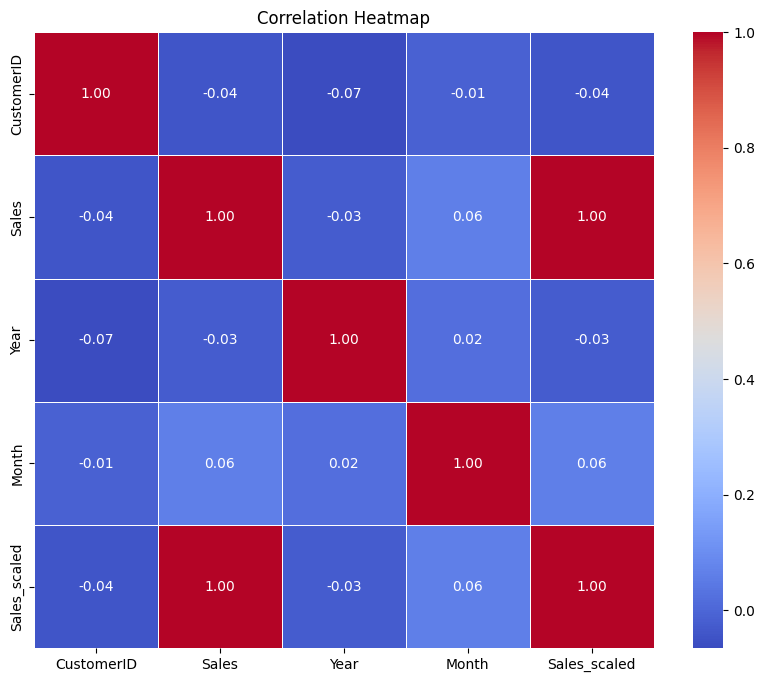

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
# Calculate correlations only for numerical columns
sns.heatmap(df.select_dtypes(include=np.number).corr(),
annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

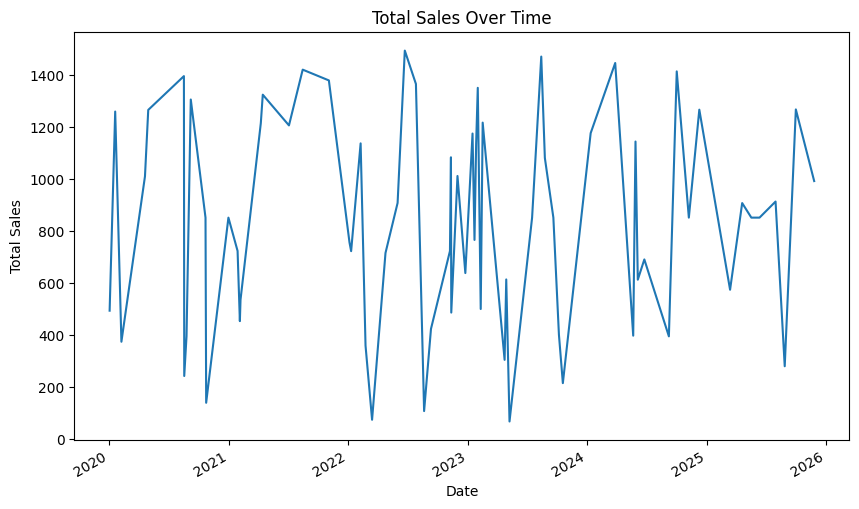

In [ ]:
# Plot sales over time
plt.figure(figsize=(10, 6))
df.groupby('Date')['Sales'].sum().plot()
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

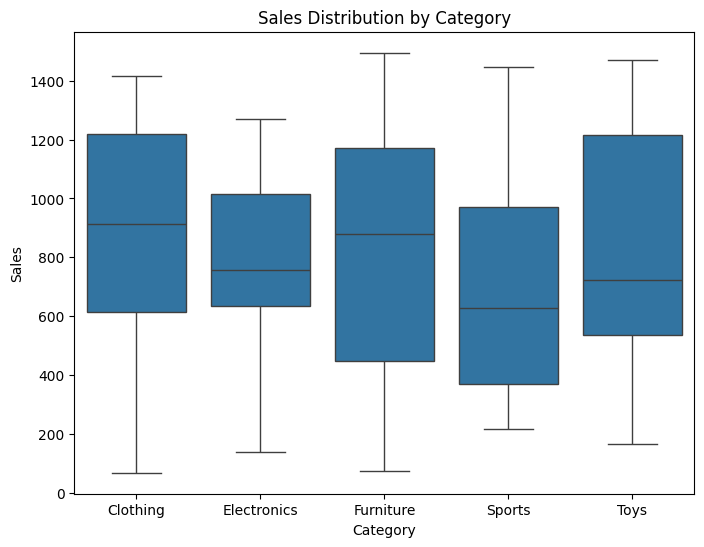

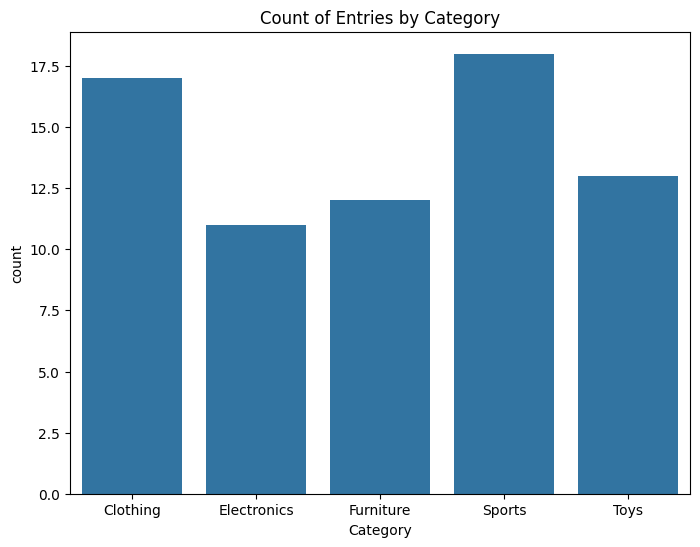

In [ ]:
# Box plot for 'Sales' by 'Category'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title('Sales Distribution by Category')
plt.show()

# Bar plot for the count of each category
plt.figure(figsize=(8, 6))
sns.countplot(x='Category', data=df)
plt.title('Count of Entries by Category')
plt.show()

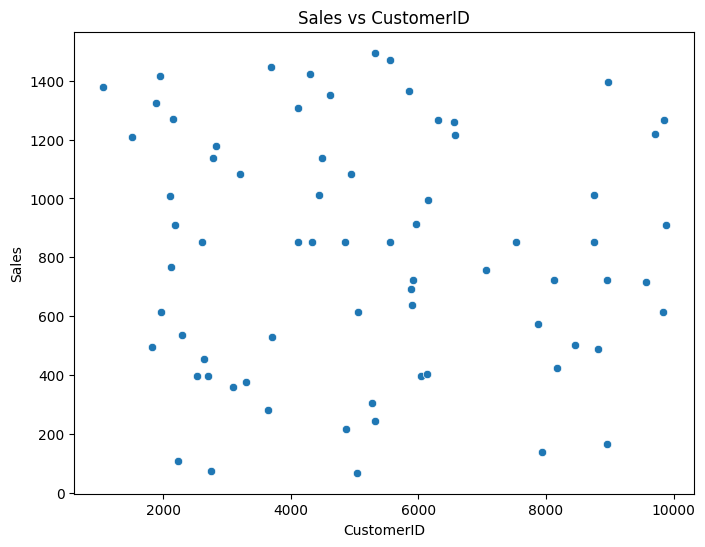

In [ ]:
# Scatter plot to identify outliers in 'Sales' vs 'CustomerID'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='CustomerID', y='Sales', data=df)
plt.title('Sales vs CustomerID')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Set the display precision for pandas to show 2 decimal places
pd.options.display.precision = 2

In [ ]:
# https://github.com/Yorko/mlcourse.ai repo
DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
# Load the telecom churn dataset from the specified URL into a pandas DataFrame
data_url = DATA_URL + "telecom_churn.csv"
df = pd.read_csv(data_url)

# Display the first few rows of the dataset to inspect the data
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
print(df.shape)


(3333, 20)


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [ ]:
print(df.columns)


Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')


In [ ]:
df["Churn"] = df["Churn"].astype("int64")


In [ ]:
df.describe(include=["object", "bool"])


,State,International plan,Voice mail plan
count,3333,3333,3333
unique,51,2,2
top,WV,No,No
freq,106,3010,2411


In [ ]:
df["Churn"].value_counts(normalize=True)


,proportion
Churn,
0,0.86
1,0.14


In [ ]:
df.sort_values(by="Total day charge", ascending=False).head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
365,CO,154,415,No,No,0,350.8,75,59.64,216.5,94,18.40,253.9,100,11.43,10.1,9,2.73,1,1
985,NY,64,415,Yes,No,0,346.8,55,58.96,249.5,79,21.21,275.4,102,12.39,13.3,9,3.59,1,1
2594,OH,115,510,Yes,No,0,345.3,81,58.70,203.4,106,17.29,217.5,107,9.79,11.8,8,3.19,1,1
156,OH,83,415,No,No,0,337.4,120,57.36,227.4,116,19.33,153.9,114,6.93,15.8,7,4.27,0,1
605,MO,112,415,No,No,0,335.5,77,57.04,212.5,109,18.06,265.0,132,11.93,12.7,8,3.43,2,1


In [ ]:
df.sort_values(by=["Churn", "Total day charge"], ascending=[True, False]).head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
688,MN,13,510,No,Yes,21,315.6,105,53.65,208.9,71,17.76,260.1,123,11.70,12.1,3,3.27,3,0
2259,NC,210,415,No,Yes,31,313.8,87,53.35,147.7,103,12.55,192.7,97,8.67,10.1,7,2.73,3,0
534,LA,67,510,No,No,0,310.4,97,52.77,66.5,123,5.65,246.5,99,11.09,9.2,10,2.48,4,0
575,SD,114,415,No,Yes,36,309.9,90,52.68,200.3,89,17.03,183.5,105,8.26,14.2,2,3.83,1,0
2858,AL,141,510,No,Yes,28,308.0,123,52.36,247.8,128,21.06,152.9,103,6.88,7.4,3,2.00,1,0


In [ ]:
df["Churn"].mean()


np.float64(0.14491449144914492)

In [ ]:
df[df["Churn"] == 1]["Total day minutes"].mean()


np.float64(206.91407867494823)

In [ ]:
df.select_dtypes(include=np.number)[df["Churn"] == 1].mean()


,0
Account length,102.66
Area code,437.82
Number vmail messages,5.12
Total day minutes,206.91
Total day calls,101.34
Total day charge,35.18
Total eve minutes,212.41
Total eve calls,100.56
Total eve charge,18.05
Total night minutes,205.23


In [ ]:
df.loc[0:5, "State":"Area code"]


,State,Account length,Area code
0,KS,128,415
1,OH,107,415
2,NJ,137,415
3,OH,84,408
4,OK,75,415
5,AL,118,510


In [ ]:
df.iloc[0:5, 0:3]


,State,Account length,Area code
0,KS,128,415
1,OH,107,415
2,NJ,137,415
3,OH,84,408
4,OK,75,415


In [ ]:
df[-1:]


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
3332,TN,74,415,No,Yes,25,234.4,113,39.85,265.9,82,22.6,241.4,77,10.86,13.7,4,3.7,0,0


In [ ]:
df[df["State"].apply(lambda state: state[0] == "W")].head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
9,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,0
26,WY,57,408,No,Yes,39,213.0,115,36.21,191.1,112,16.24,182.7,115,8.22,9.5,3,2.57,0,0
44,WI,64,510,No,No,0,154.0,67,26.18,225.8,118,19.19,265.3,86,11.94,3.5,3,0.95,1,0
49,WY,97,415,No,Yes,24,133.2,135,22.64,217.2,58,18.46,70.6,79,3.18,11.0,3,2.97,1,0
54,WY,87,415,No,No,0,151.0,83,25.67,219.7,116,18.67,203.9,127,9.18,9.7,3,2.62,5,1


In [ ]:
d = {"No": False, "Yes": True}
df["International plan"] = df["International plan"].map(d)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,False,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,False,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,False,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,True,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,True,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [ ]:
df = df.replace({"Voice mail plan": d})
df.head()

/tmp/ipython-input-1212166602.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"Voice mail plan": d})


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,False,True,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,False,True,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,False,False,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,True,False,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,True,False,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [ ]:
columns_to_show = ["Total day minutes", "Total eve minutes", "Total night minutes"]

df.groupby(["Churn"])[columns_to_show].describe(percentiles=[])

Total day minutes                                   Total eve minutes  \
                  count    mean    std  min    50%    max             count   
Churn                                                                         
0                2850.0  175.18  50.18  0.0  177.2  315.6            2850.0   
1                 483.0  206.91  69.00  0.0  217.6  350.8             483.0   

                                         Total night minutes                 \
         mean    std   min    50%    max               count    mean    std   
Churn                                                                         
0      199.04  50.29   0.0  199.6  361.8              2850.0  200.13  51.11   
1      212.41  51.73  70.9  211.3  363.7               483.0  205.23  47.13   

                            
        min     50%    max  
Churn                       
0      23.2  200.25  395.0  
1      47.4  204.80  354.9

In [ ]:
columns_to_show = ["Total day minutes", "Total eve minutes", "Total night minutes"]

df.groupby(["Churn"])[columns_to_show].agg(["mean", "std", "min", "max"])

Total day minutes                    Total eve minutes               \
                   mean    std  min    max              mean    std   min   
Churn                                                                       
0                175.18  50.18  0.0  315.6            199.04  50.29   0.0   
1                206.91  69.00  0.0  350.8            212.41  51.73  70.9   

             Total night minutes                      
         max                mean    std   min    max  
Churn                                                 
0      361.8              200.13  51.11  23.2  395.0  
1      363.7              205.23  47.13  47.4  354.9

In [ ]:
pd.crosstab(df["Churn"], df["International plan"])

International plan,False,True
Churn,,
0,2664,186
1,346,137


In [ ]:
pd.crosstab(df["Churn"], df["Voice mail plan"], normalize=True)

Voice mail plan,False,True
Churn,,
0,0.60,0.25
1,0.12,0.02


In [ ]:
df.pivot_table(
["Total day calls", "Total eve calls", "Total night calls"],
["Area code"],
aggfunc="mean",
)

,Total day calls,Total eve calls,Total night calls
Area code,,,
408,100.50,99.79,99.04
415,100.58,100.50,100.40
510,100.10,99.67,100.60


In [ ]:
total_calls = (
df["Total day calls"]
+ df["Total eve calls"]
+ df["Total night calls"]
+ df["Total intl calls"]
)
df.insert(loc=len(df.columns), column="Total calls", value=total_calls)
# loc parameter is the number of columns after which to insert the Series object
# we set it to len(df.columns) to paste it at the very end of the dataframe
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Total calls
0,KS,128,415,False,True,25,265.1,110,45.07,197.4,...,16.78,244.7,91,11.01,10.0,3,2.70,1,0,303
1,OH,107,415,False,True,26,161.6,123,27.47,195.5,...,16.62,254.4,103,11.45,13.7,3,3.70,1,0,332
2,NJ,137,415,False,False,0,243.4,114,41.38,121.2,...,10.30,162.6,104,7.32,12.2,5,3.29,0,0,333
3,OH,84,408,True,False,0,299.4,71,50.90,61.9,...,5.26,196.9,89,8.86,6.6,7,1.78,2,0,255
4,OK,75,415,True,False,0,166.7,113,28.34,148.3,...,12.61,186.9,121,8.41,10.1,3,2.73,3,0,359


In [ ]:
df["Total charge"] = (
df["Total day charge"]
+ df["Total eve charge"]
+ df["Total night charge"]
+ df["Total intl charge"]
)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,Total calls,Total charge
0,KS,128,415,False,True,25,265.1,110,45.07,197.4,...,244.7,91,11.01,10.0,3,2.70,1,0,303,75.56
1,OH,107,415,False,True,26,161.6,123,27.47,195.5,...,254.4,103,11.45,13.7,3,3.70,1,0,332,59.24
2,NJ,137,415,False,False,0,243.4,114,41.38,121.2,...,162.6,104,7.32,12.2,5,3.29,0,0,333,62.29
3,OH,84,408,True,False,0,299.4,71,50.90,61.9,...,196.9,89,8.86,6.6,7,1.78,2,0,255,66.80
4,OK,75,415,True,False,0,166.7,113,28.34,148.3,...,186.9,121,8.41,10.1,3,2.73,3,0,359,52.09


In [ ]:
# get rid of just created columns
df.drop(["Total charge", "Total calls"], axis=1, inplace=True)
# and here’s how you can delete rows
df.drop([1, 2]).head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,False,True,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
3,OH,84,408,True,False,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,True,False,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
5,AL,118,510,True,False,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,0
6,MA,121,510,False,True,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0


In [ ]:
pd.crosstab(df["Churn"], df["International plan"], margins=True)


International plan,False,True,All
Churn,,,
0,2664,186,2850
1,346,137,483
All,3010,323,3333


In [ ]:
# some imports to set up plotting
import matplotlib.pyplot as plt

# !pip install seaborn
import seaborn as sns

# import some nice vis settings
sns.set()
# Graphics in the Retina format are more sharp and legible
%config InlineBackend.figure_format = 'retina'

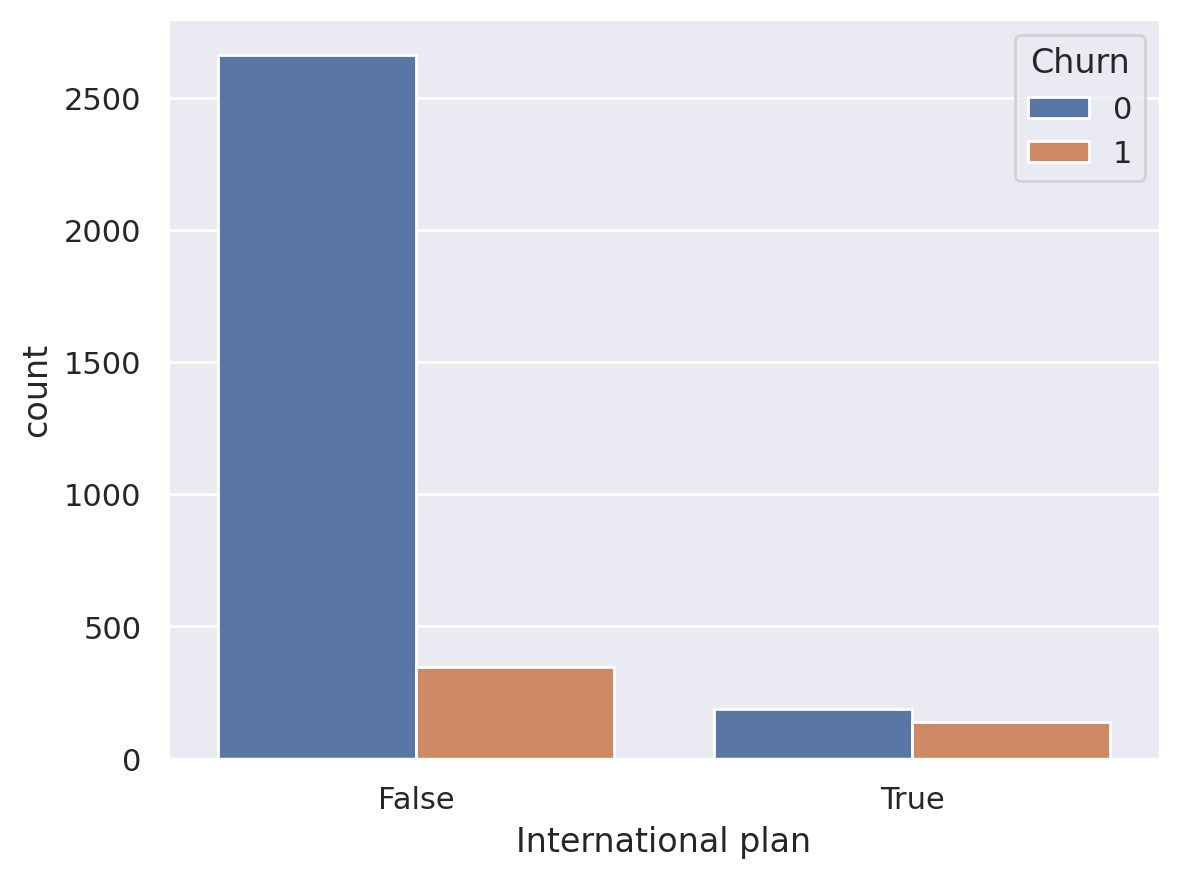

In [ ]:
sns.countplot(x="International plan", hue="Churn", data=df);

In [ ]:
pd.crosstab(df["Churn"], df["Customer service calls"], margins=True)


Customer service calls,0,1,2,3,4,5,6,7,8,9,All
Churn,,,,,,,,,,,
0,605,1059,672,385,90,26,8,4,1,0,2850
1,92,122,87,44,76,40,14,5,1,2,483
All,697,1181,759,429,166,66,22,9,2,2,3333


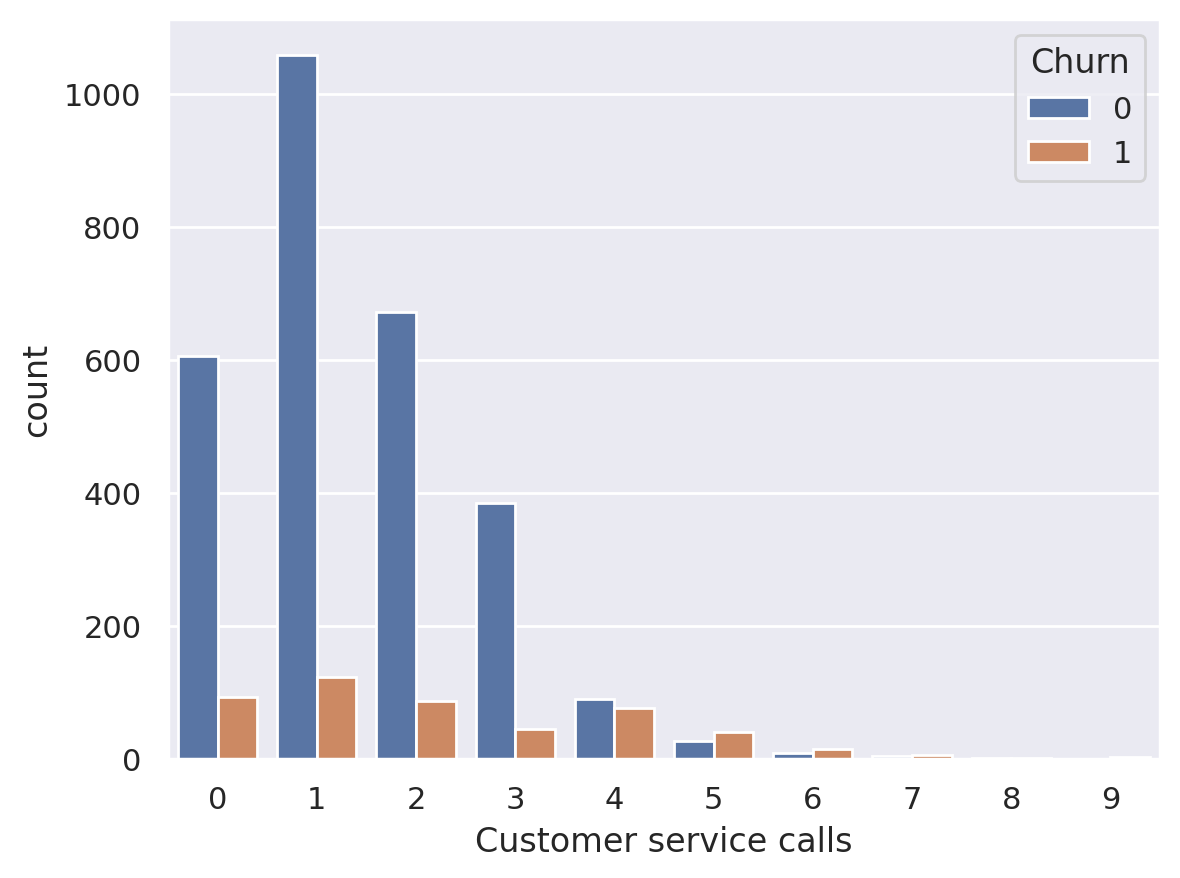

In [ ]:
sns.countplot(x="Customer service calls", hue="Churn", data=df);


In [ ]:
df["Many_service_calls"] = (df["Customer service calls"] > 3).astype("int")

pd.crosstab(df["Many_service_calls"], df["Churn"], margins=True)

Churn,0,1,All
Many_service_calls,,,
0,2721,345,3066
1,129,138,267
All,2850,483,3333


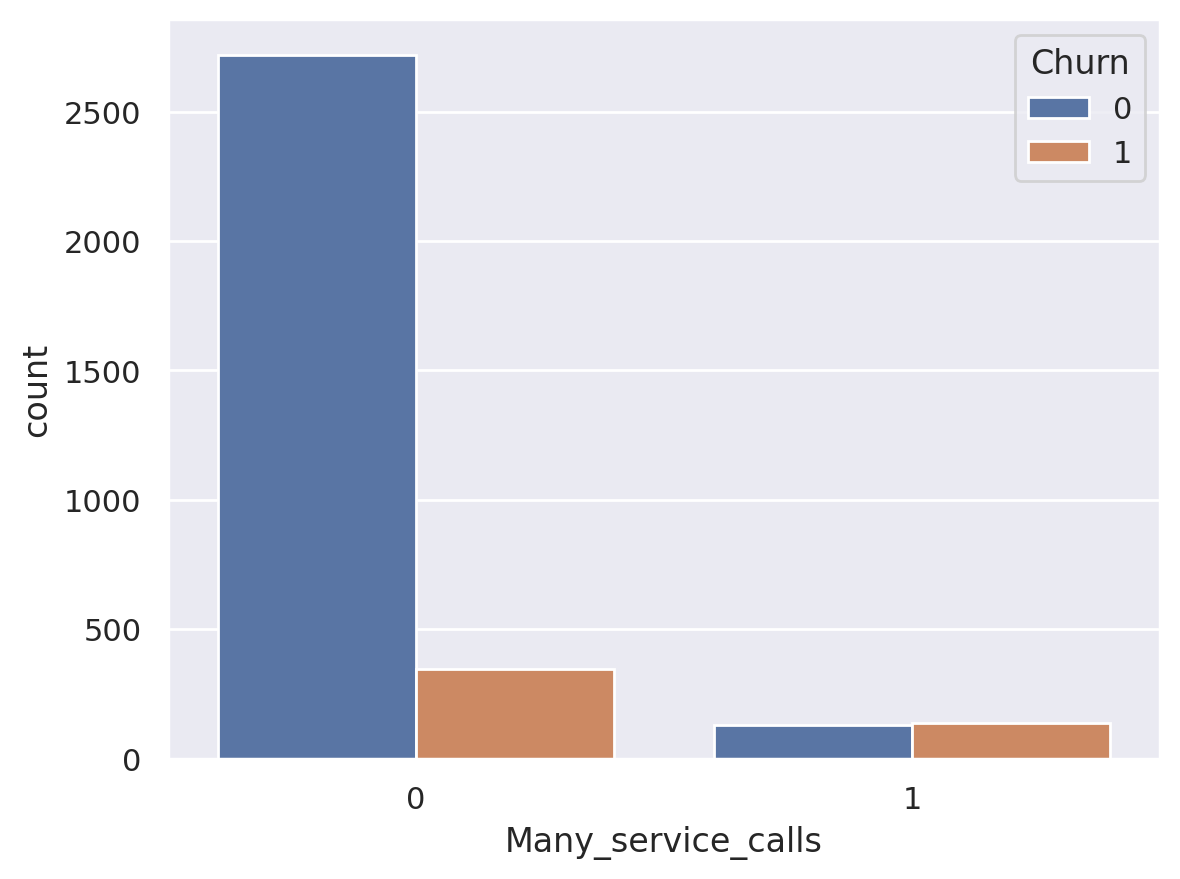

In [ ]:
sns.countplot(x="Many_service_calls", hue="Churn", data=df);


In [ ]:
pd.crosstab(df["Many_service_calls"] & df["International plan"], df["Churn"], margins=True)


Churn,0,1,All
row_0,,,
False,2841,464,3305
True,9,19,28
All,2850,483,3333


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"


In [ ]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
df = pd.read_csv(DATA_PATH + "mlbootcamp5_train.csv", sep=";")
print("Dataset size: ", df.shape)
df.head()

Dataset size:  (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
%matplotlib inline

In [ ]:
from google.colab import drive


In [ ]:
#load the train dataset
train = pd.read_csv('/content/titanic.csv')

In [ ]:
display(train.head())


,PassengerId,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,Braund,Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.28,C85,C
2,3,1,3,Heikkinen,Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.10,C123,S
4,5,0,3,Allen,Mr. William Henry,male,35.0,0,0,373450,8.05,NaN,S


In [ ]:
train = train.set_index('PassengerId')


In [ ]:
test=pd.read_csv('/content/titanic.csv')

In [ ]:
display(test.head())


,PassengerId,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,Braund,Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.28,C85,C
2,3,1,3,Heikkinen,Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.10,C123,S
4,5,0,3,Allen,Mr. William Henry,male,35.0,0,0,373450,8.05,NaN,S


In [ ]:
train.shape


(156, 12)

In [ ]:
train.head()


,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,,
1,0,3,Braund,Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.25,NaN,S
2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.28,C85,C
3,1,3,Heikkinen,Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.10,C123,S
5,0,3,Allen,Mr. William Henry,male,35.0,0,0,373450,8.05,NaN,S


In [ ]:
datadict = pd.DataFrame(train.dtypes)
datadict

,0
Survived,int64
Pclass,int64
Lname,object
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
datadict['MissingVal'] = train.isnull().sum()
datadict

,0,MissingVal
Survived,int64,0
Pclass,int64,0
Lname,object,0
Name,object,0
Sex,object,0
Age,float64,30
SibSp,int64,0
Parch,int64,0
Ticket,object,0
Fare,float64,0


In [ ]:
datadict['NUnique']=train.nunique()
datadict

,0,MissingVal,NUnique
Survived,int64,0,2
Pclass,int64,0,3
Lname,object,0,141
Name,object,0,152
Sex,object,0,2
Age,float64,30,56
SibSp,int64,0,6
Parch,int64,0,5
Ticket,object,0,145
Fare,float64,0,93


In [ ]:
datadict['Count']=train.count()
datadict

,0,MissingVal,NUnique,Count
Survived,int64,0,2,156
Pclass,int64,0,3,156
Lname,object,0,141,156
Name,object,0,152,156
Sex,object,0,2,156
Age,float64,30,56,126
SibSp,int64,0,6,156
Parch,int64,0,5,156
Ticket,object,0,145,156
Fare,float64,0,93,156


In [ ]:
datadict = datadict.rename(columns={0:'DataType'})
datadict

,DataType,MissingVal,NUnique,Count
Survived,int64,0,2,156
Pclass,int64,0,3,156
Lname,object,0,141,156
Name,object,0,152,156
Sex,object,0,2,156
Age,float64,30,56,126
SibSp,int64,0,6,156
Parch,int64,0,5,156
Ticket,object,0,145,156
Fare,float64,0,93,156


In [ ]:
train.describe(include=['object'])

,Lname,Name,Sex,Ticket,Cabin,Embarked
count,156,156,156,156,31,155
unique,141,152,2,145,28,3
top,Andersson,Mr. William Henry,male,113803,C123,S
freq,4,2,100,2,2,110


In [ ]:
train.describe(include=['number'])

,Survived,Pclass,Age,SibSp,Parch,Fare
count,156.00,156.00,126.00,156.00,156.00,156.00
mean,0.35,2.42,28.14,0.62,0.40,28.11
std,0.48,0.80,14.61,1.06,0.87,39.40
min,0.00,1.00,0.83,0.00,0.00,6.75
25%,0.00,2.00,19.00,0.00,0.00,8.00
50%,0.00,3.00,26.00,0.00,0.00,14.45
75%,1.00,3.00,35.00,1.00,0.00,30.37
max,1.00,3.00,71.00,5.00,5.00,263.00


In [ ]:
train.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.65
1,0.35


/tmp/ipython-input-1338412997.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Fare'], kde=True, ax=axes[1,2])
/tmp/ipython-input-1338412997.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(), kde=True, ax=axes[1,3])


<Axes: xlabel='Age', ylabel='Density'>

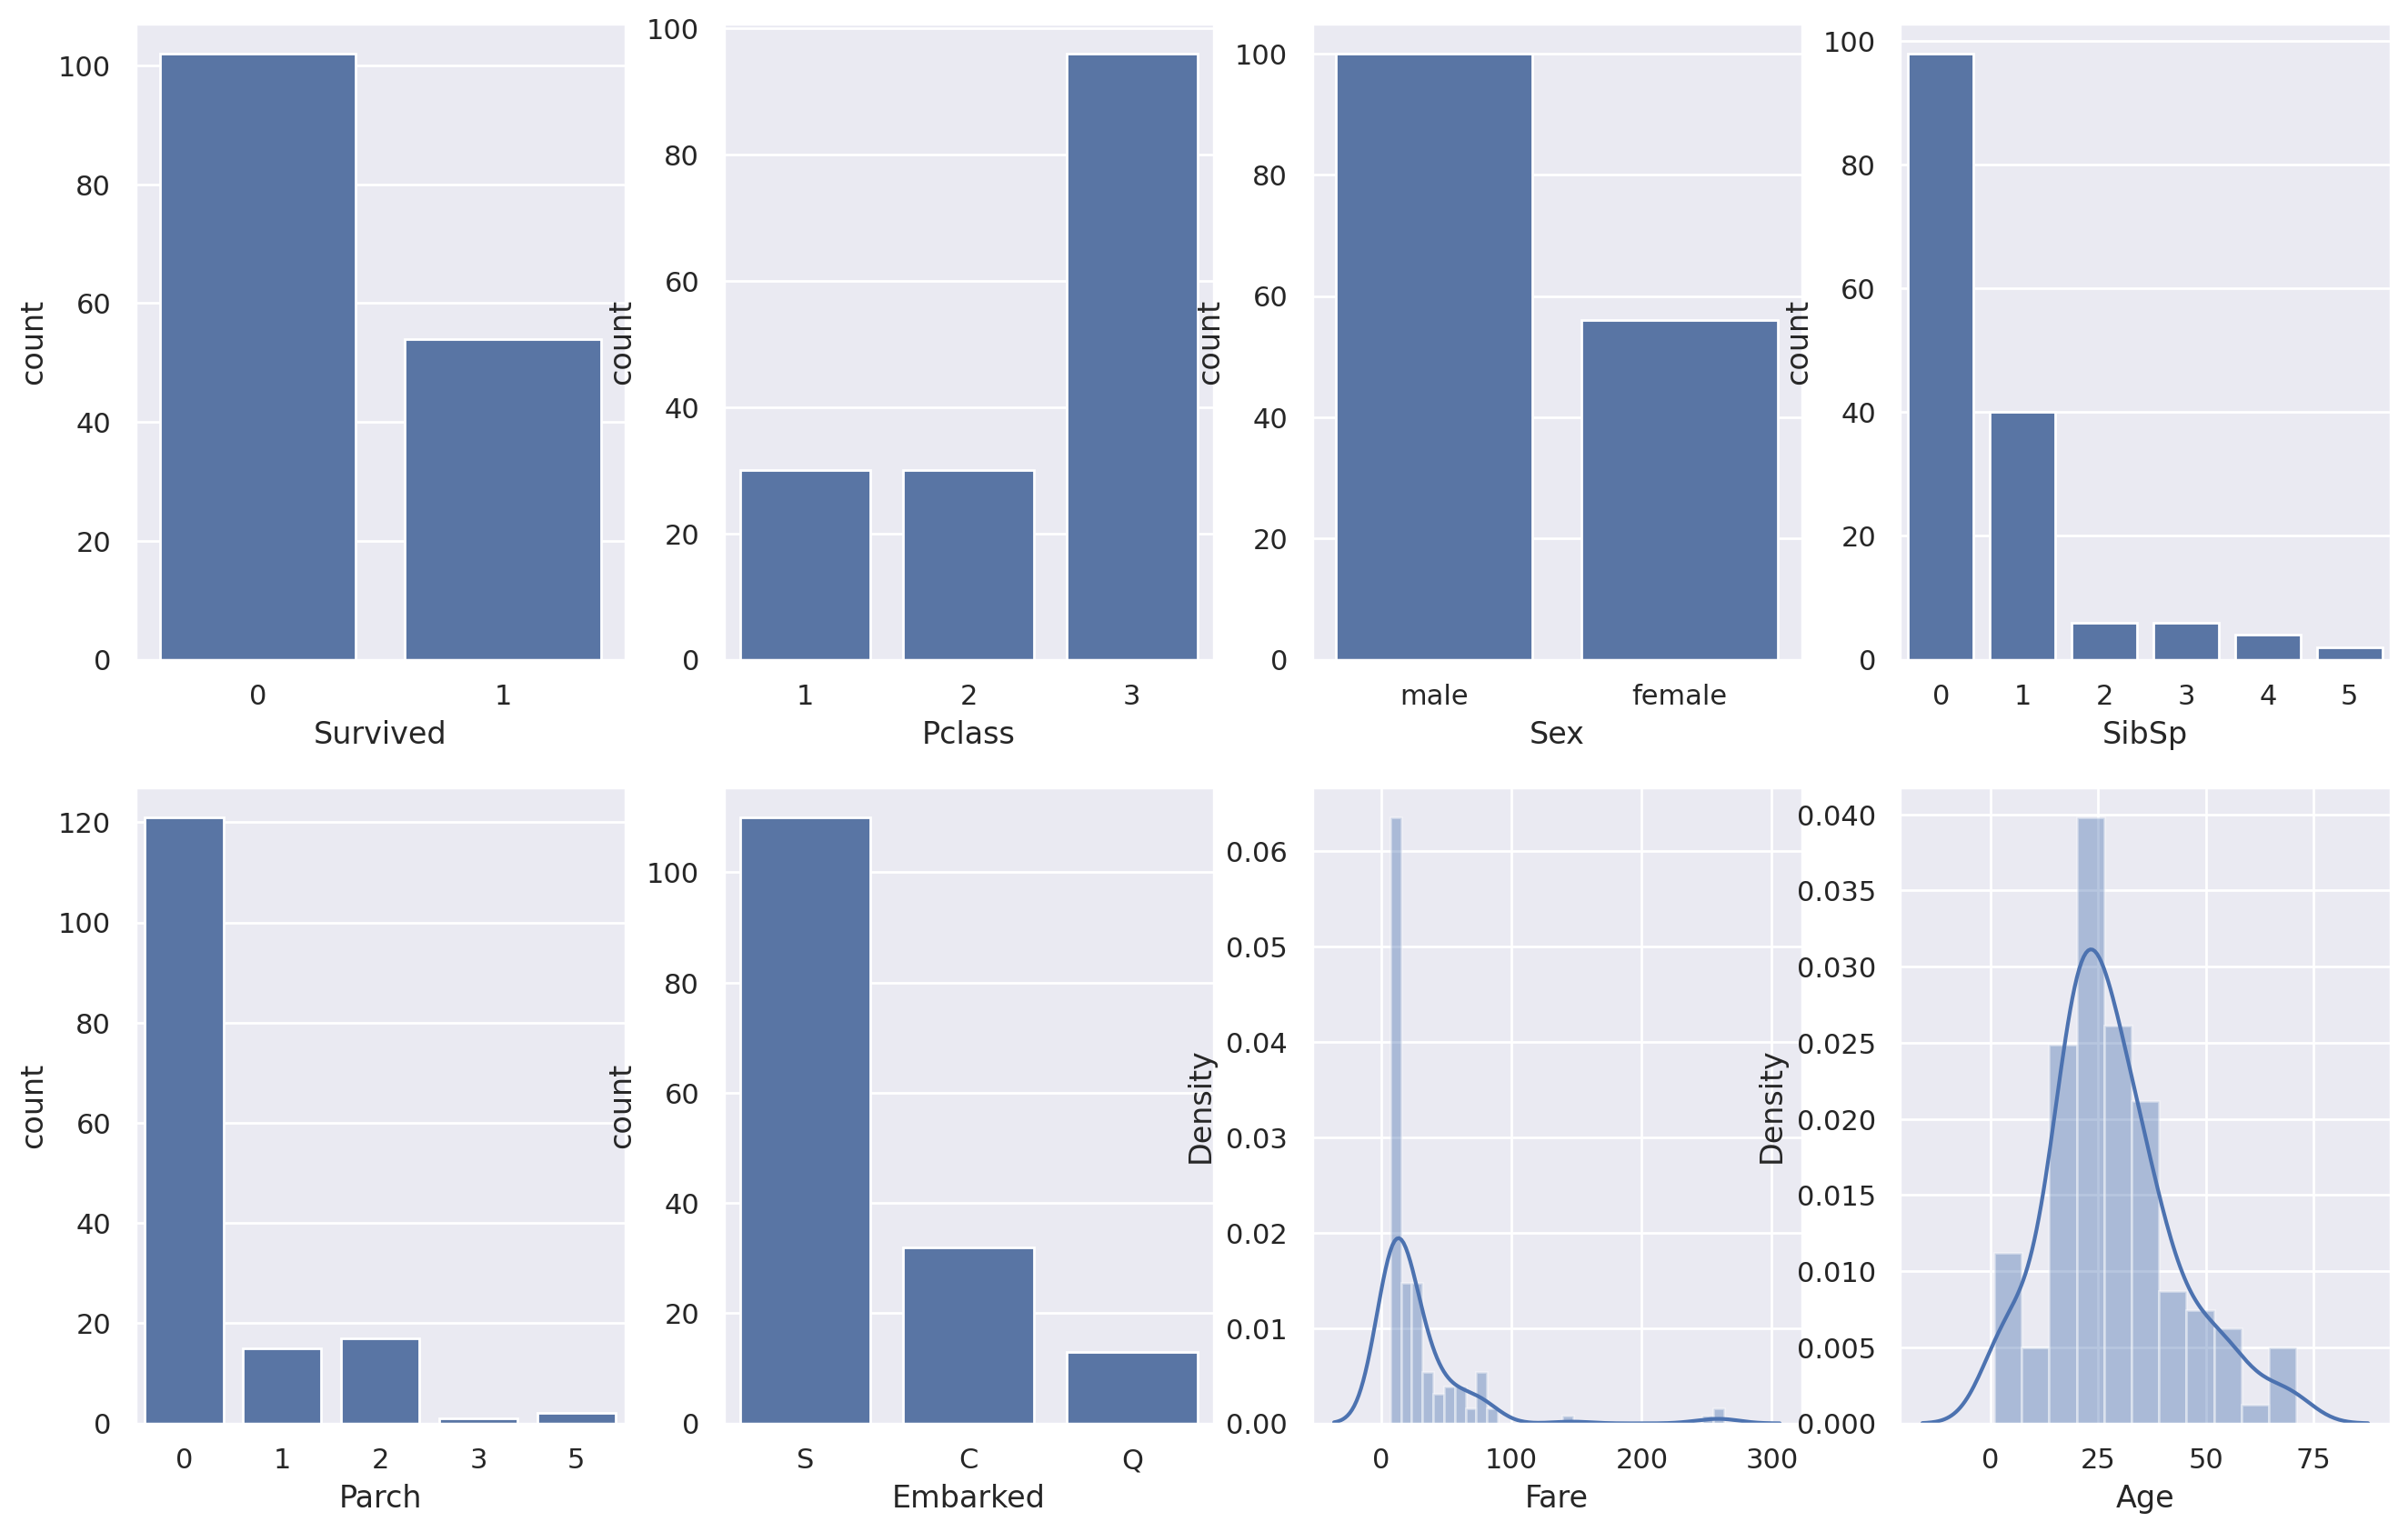

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
sns.countplot(x='Survived', data=train, ax=axes[0,0]) # Specify 'x' for the column name
sns.countplot(x='Pclass', data=train, ax=axes[0,1])  # Specify 'x' for the column name
sns.countplot(x='Sex', data=train, ax=axes[0,2])   # Specify 'x' for the column name
sns.countplot(x='SibSp', data=train, ax=axes[0,3]) # Specify 'x' for the column name
sns.countplot(x='Parch', data=train, ax=axes[1,0]) # Specify 'x' for the column name
sns.countplot(x='Embarked', data=train, ax=axes[1,1]) # Specify 'x' for the column name
sns.distplot(train['Fare'], kde=True, ax=axes[1,2])
sns.distplot(train['Age'].dropna(), kde=True, ax=axes[1,3])

<Axes: xlabel='Survived', ylabel='Fare'>

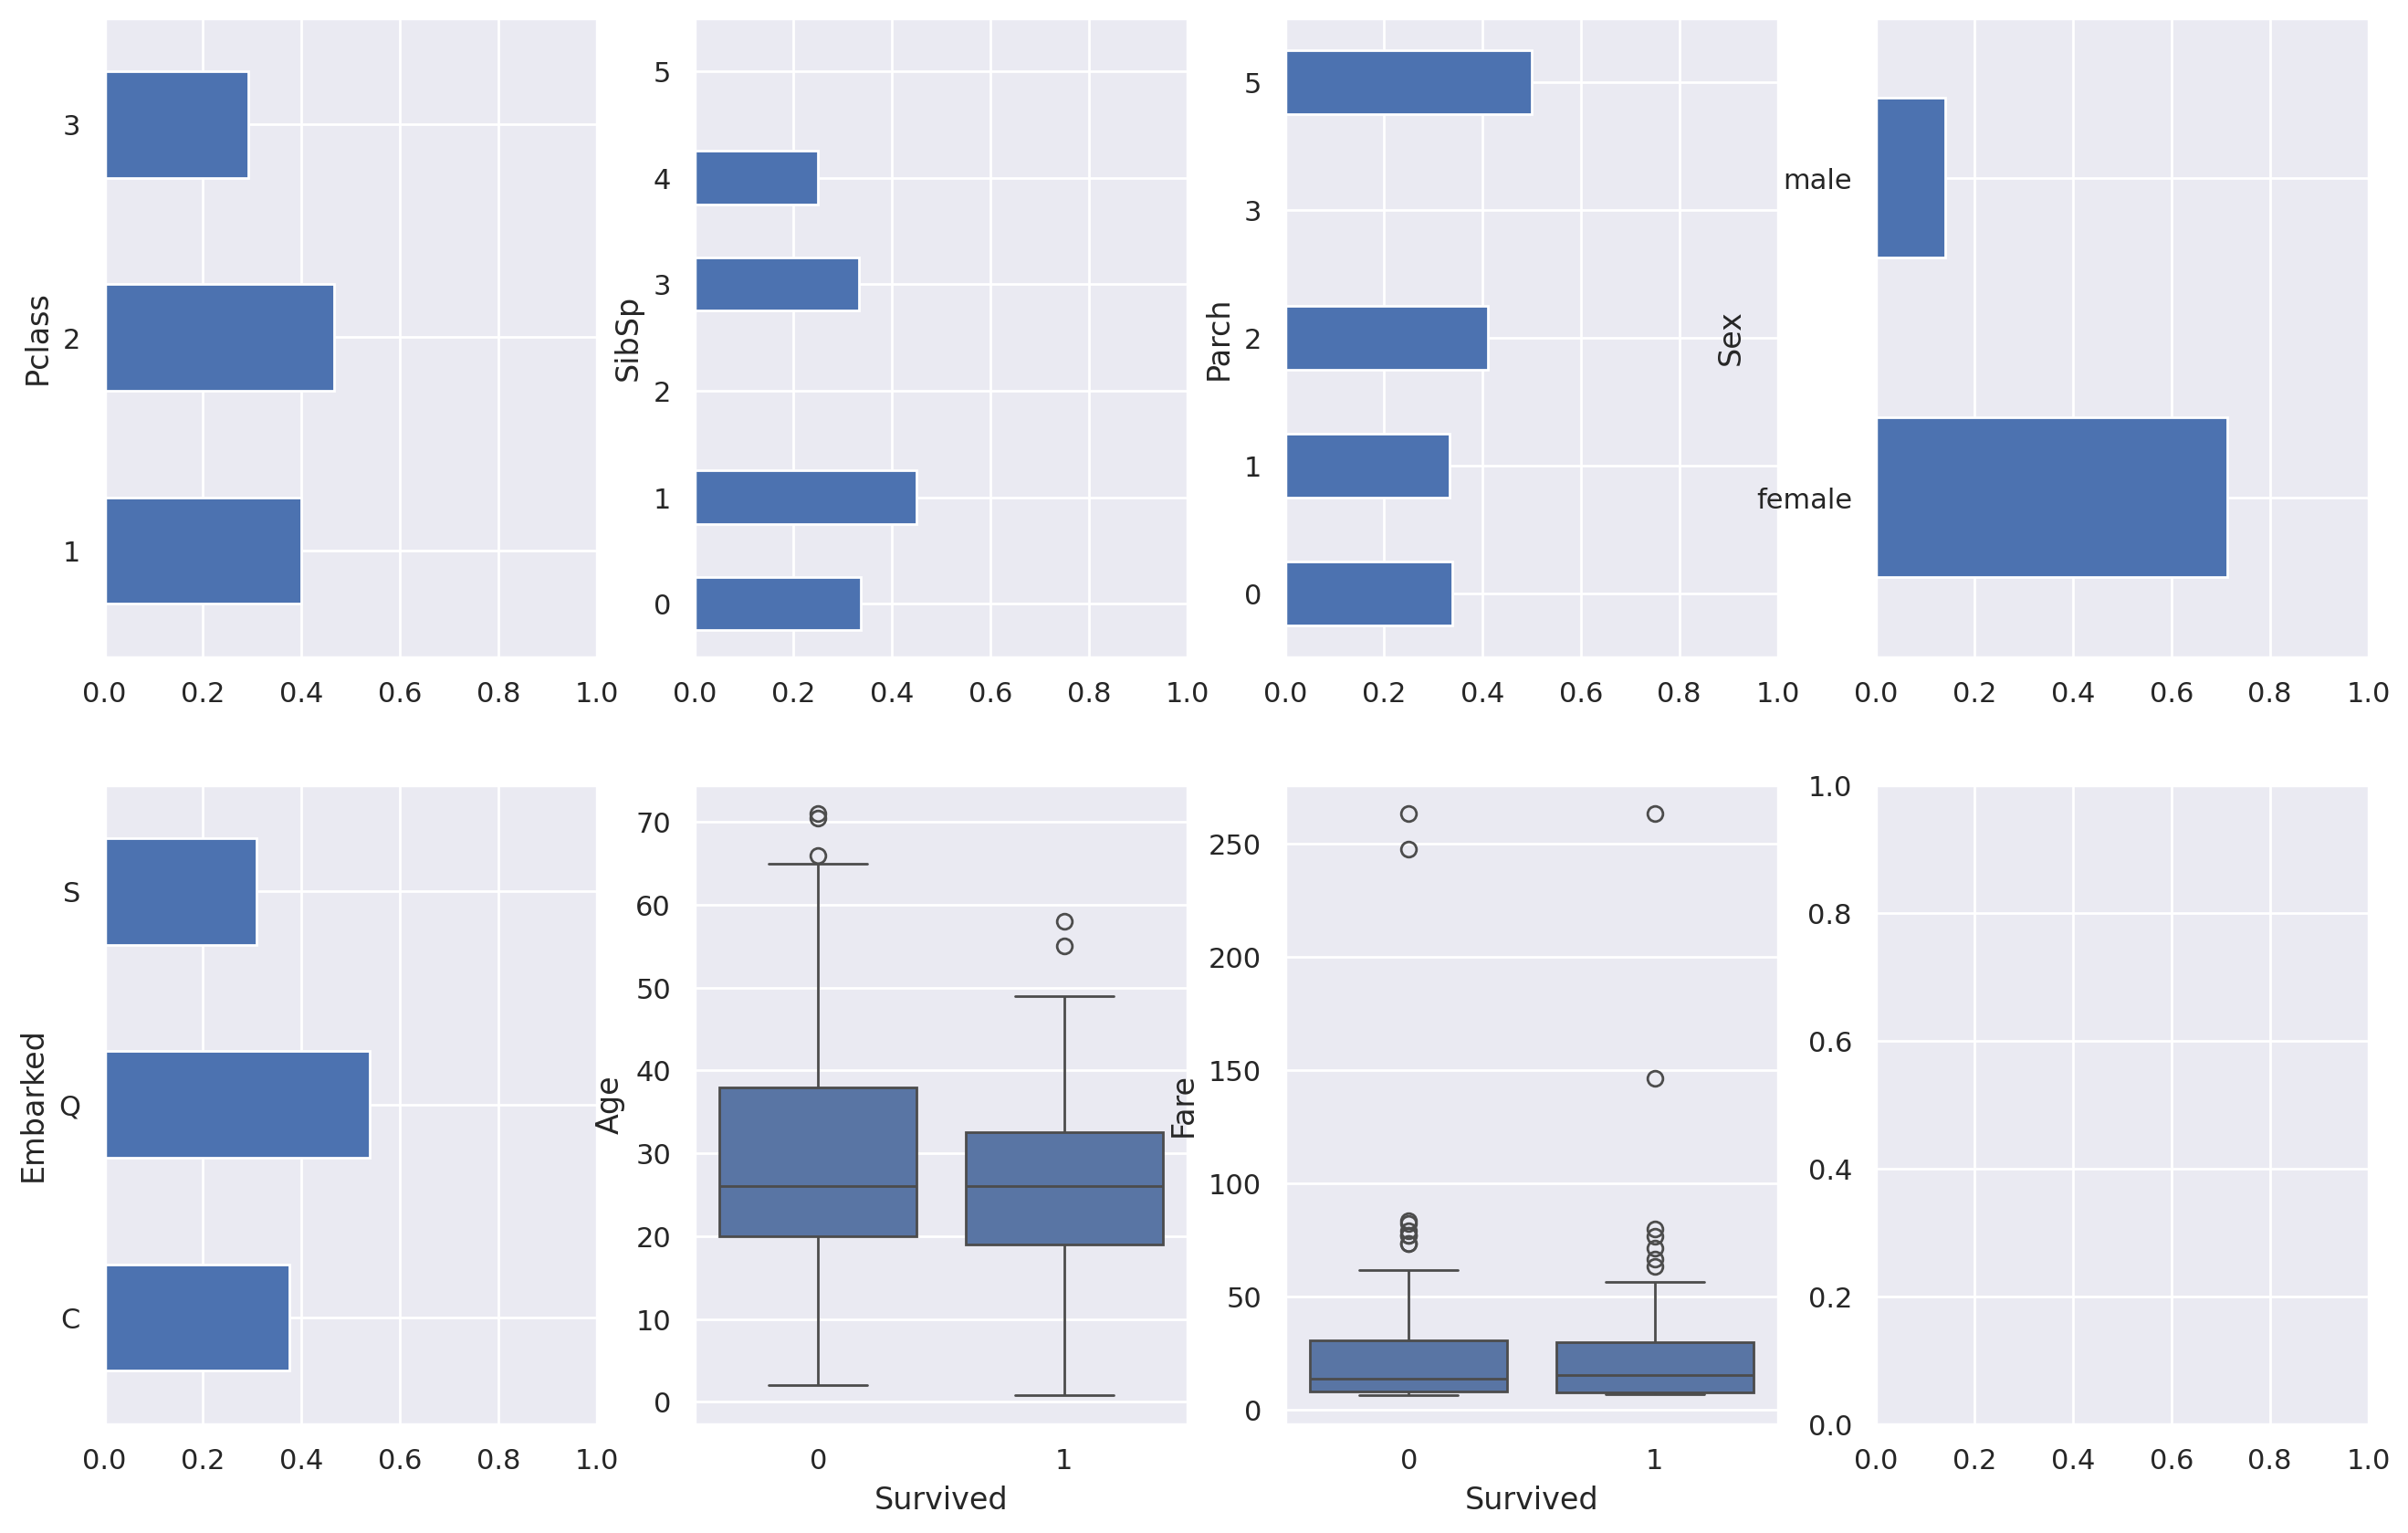

In [ ]:
figbi, axesbi = plt.subplots(2, 4, figsize=(16, 10))
train.groupby('Pclass')['Survived'].mean().plot(kind='barh',ax=axesbi[0,0],xlim=[0,1])
train.groupby('SibSp')['Survived'].mean().plot(kind='barh',ax=axesbi[0,1],xlim=[0,1])
train.groupby('Parch')['Survived'].mean().plot(kind='barh',ax=axesbi[0,2],xlim=[0,1])
train.groupby('Sex')['Survived'].mean().plot(kind='barh',ax=axesbi[0,3],xlim=[0,1])
train.groupby('Embarked')['Survived'].mean().plot(kind='barh',ax=axesbi[1,0],xlim=[0,1])
sns.boxplot(x="Survived", y="Age", data=train,ax=axesbi[1,1])
sns.boxplot(x="Survived", y="Fare", data=train,ax=axesbi[1,2])

<Axes: >

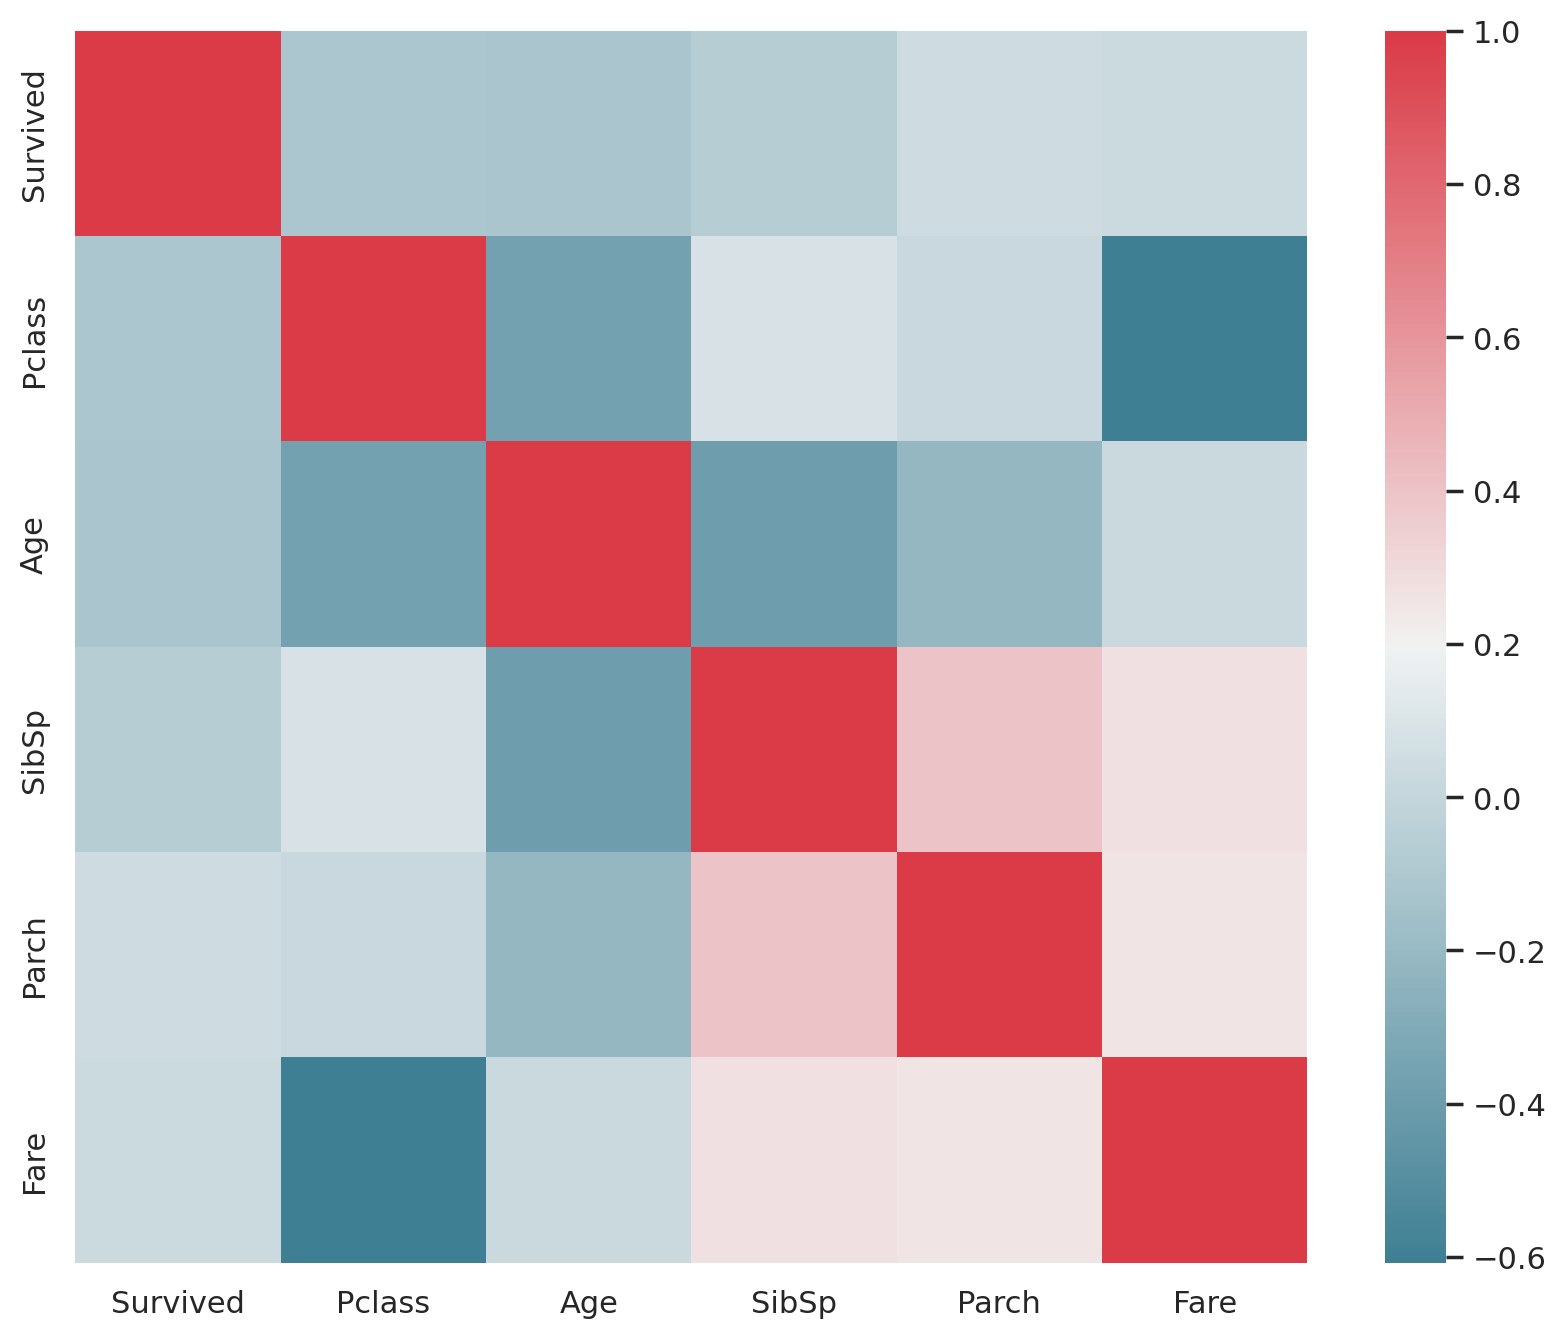

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

f, ax = plt.subplots(figsize=(10, 8))
# Select only numerical features for correlation calculation
numerical_features = train.select_dtypes(include=['number'])
corr = numerical_features.corr()
sns.heatmap(corr,
mask=np.zeros_like(corr, dtype=bool), # Changed np.bool to bool
cmap=sns.diverging_palette(220, 10, as_cmap=True),
square=True, ax=ax)

In [ ]:
train['Name_len']=train.Name.str.len()


In [ ]:
train['Ticket_First']=train.Ticket.str[0]


In [ ]:
train['FamilyCount']=train.SibSp+train.Parch


In [ ]:
train['Cabin_First']=train.Cabin.str[0]


In [ ]:
train['title'] = train.Name.str.extract('\, ([A-Z][^ ]*\.)',expand=False)


<>:1: SyntaxWarning: invalid escape sequence '\,'
<>:1: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipython-input-3595378177.py:1: SyntaxWarning: invalid escape sequence '\,'
  train['title'] = train.Name.str.extract('\, ([A-Z][^ ]*\.)',expand=False)


In [ ]:
train.title.value_counts().reset_index()

,title,count


In [ ]:
train


,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_len,Ticket_First,FamilyCount,Cabin_First,title
PassengerId,,,,,,,,,,,,,,,,,
1,0,3,Braund,Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.25,NaN,S,16,A,1,NaN,NaN
2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,71.28,C85,C,43,P,1,C,NaN
3,1,3,Heikkinen,Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,12,S,0,NaN,NaN
4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.10,C123,S,35,1,1,C,NaN
5,0,3,Allen,Mr. William Henry,male,35.0,0,0,373450,8.05,NaN,S,18,3,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,1,1,Pears,Mrs. Thomas (Edith Wearne),female,22.0,1,0,113776,66.60,C2,S,27,1,1,C,NaN
153,0,3,Meo,Mr. Alfonzo,male,55.5,0,0,A.5. 11206,8.05,NaN,S,12,A,0,NaN,NaN
154,0,3,van Billiard,Mr. Austin Blyler,male,40.5,0,2,A/5. 851,14.50,NaN,S,18,A,2,NaN,NaN


In [ ]:
print((train.Fare == 0).sum())


0


In [ ]:
train.Fare = train.Fare.replace(0, np.nan)


In [ ]:
print((train.Fare == 0).sum())

0


In [ ]:
train[train.Fare.isnull()].index


Index([], dtype='int64', name='PassengerId')

In [ ]:
train.Fare.mean()


np.float64(28.109587179487182)

In [ ]:
train.Fare.fillna(train.Fare.mean(),inplace=True)


/tmp/ipython-input-3976275052.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Fare.fillna(train.Fare.mean(),inplace=True)


In [ ]:
train[train.Fare.isnull()]


,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_len,Ticket_First,FamilyCount,Cabin_First,title
PassengerId,,,,,,,,,,,,,,,,,


In [ ]:
print((train.Age == 0).sum())


0


In [ ]:
train.Age.fillna(train.Age.mean(),inplace=True)


/tmp/ipython-input-3810257373.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Age.fillna(train.Age.mean(),inplace=True)


In [ ]:
train[train.Age.isnull()]


,Survived,Pclass,Lname,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_len,Ticket_First,FamilyCount,Cabin_First,title
PassengerId,,,,,,,,,,,,,,,,,


In [ ]:
train.Cabin.isnull().mean()


np.float64(0.8012820512820513)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 1 to 156
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      156 non-null    int64  
 1   Pclass        156 non-null    int64  
 2   Lname         156 non-null    object 
 3   Name          156 non-null    object 
 4   Sex           156 non-null    object 
 5   Age           156 non-null    float64
 6   SibSp         156 non-null    int64  
 7   Parch         156 non-null    int64  
 8   Ticket        156 non-null    object 
 9   Fare          156 non-null    float64
 10  Cabin         31 non-null     object 
 11  Embarked      155 non-null    object 
 12  Name_len      156 non-null    int64  
 13  Ticket_First  156 non-null    object 
 14  FamilyCount   156 non-null    int64  
 15  Cabin_First   31 non-null     object 
 16  title         0 non-null      object 
dtypes: float64(2), int64(6), object(9)
memory usage: 21.9+ KB


In [ ]:
train.columns

Index(['Survived', 'Pclass', 'Lname', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Name_len', 'Ticket_First',
       'FamilyCount', 'Cabin_First', 'title'],
      dtype='object')

In [ ]:
trainML = train[['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
'Fare', 'Embarked', 'Name_len', 'Ticket_First', 'FamilyCount',
'title']]

In [ ]:
trainML = trainML.dropna()

In [ ]:
trainML.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [ ]:
##page91

In [ ]:
##page91


## lab 5

In [ ]:
# Matplotlib forms basis for visualization in Python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# We will use the Seaborn library
import seaborn as sns

sns.set()

# Graphics in SVG format are more sharp and legible
%config InlineBackend.figure_format = 'svg'

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"


In [ ]:
data_url = DATA_URL + "telecom_churn.csv"
df = pd.read_csv(data_url)

In [ ]:
df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


array([[<Axes: title={'center': 'Total day minutes'}>,
        <Axes: title={'center': 'Total intl calls'}>]], dtype=object)

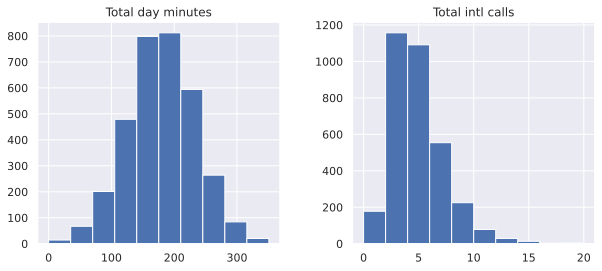

In [ ]:
# Specify the features to be visualized
selected_features = ["Total day minutes", "Total intl calls"]

# Plot histograms for the selected features with specified figure size
df[selected_features].hist(figsize=(10, 4))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

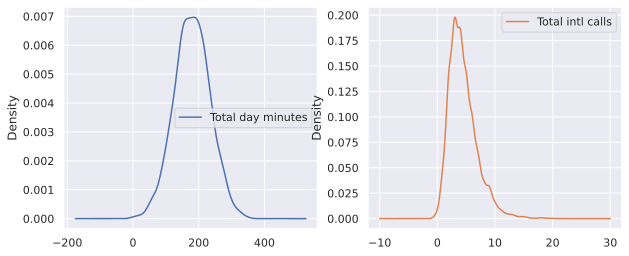

In [ ]:
# Create density plots for the specified features with separate subplots
df[selected_features].plot(
kind="density",
subplots=True,
layout=(1, 2),
sharex=False,
figsize=(10, 4)
)

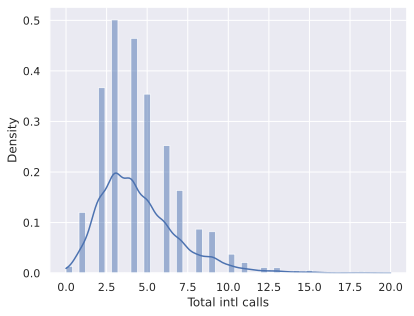

In [ ]:
sns.histplot(df["Total intl calls"], kde=True, stat="density");


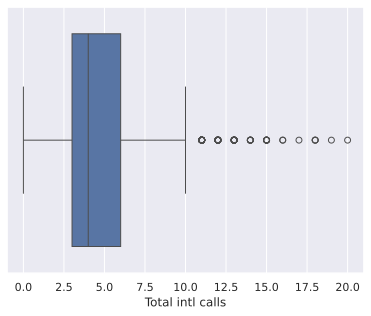

In [ ]:
sns.boxplot(x="Total intl calls", data=df);


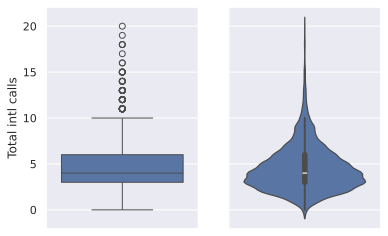

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(6, 4))
sns.boxplot(data=df["Total intl calls"], ax=axes[0])
sns.violinplot(data=df["Total intl calls"], ax=axes[1]);

In [ ]:
df[selected_features].describe()


,Total day minutes,Total intl calls
count,3333.00,3333.00
mean,179.78,4.48
std,54.47,2.46
min,0.00,0.00
25%,143.70,3.00
50%,179.40,4.00
75%,216.40,6.00
max,350.80,20.00


In [ ]:
df["Churn"].value_counts()


,count
Churn,
False,2850
True,483


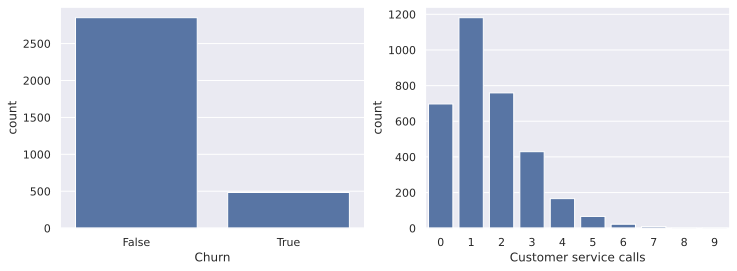

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

sns.countplot(x="Churn", data=df, ax=axes[0])
sns.countplot(x="Customer service calls", data=df, ax=axes[1]);

<Axes: >

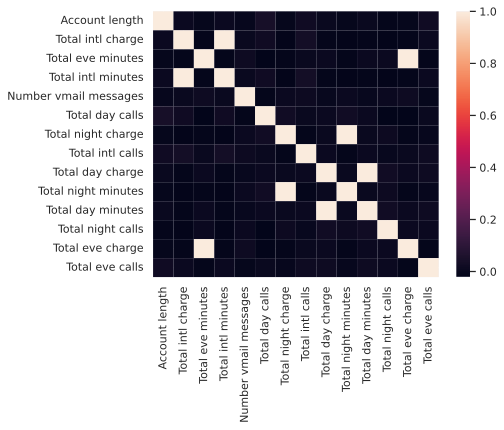

In [ ]:
# Drop non-numerical variables
numerical = list(
    set(df.columns) - set([
        "State",
        "International plan",
        "Voice mail plan",
        "Area code",
        "Churn",
        "Customer service calls"
    ])
)

# Calculate and plot
corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix)

In [ ]:
numerical = list(
    set(numerical) - set([
        "Total day charge",
        "Total eve charge",
        "Total night charge",
        "Total intl charge"
    ])
)

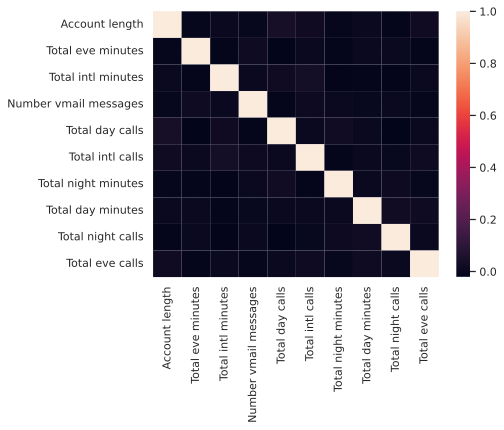

In [ ]:
corr_matrix = df[numerical].corr()
sns.heatmap(corr_matrix);

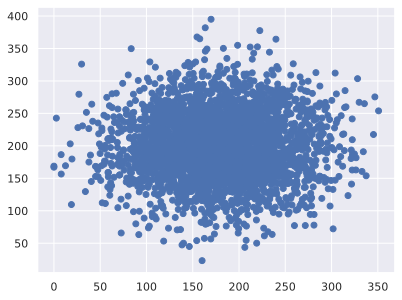

In [ ]:
plt.scatter(df["Total day minutes"], df["Total night minutes"]);


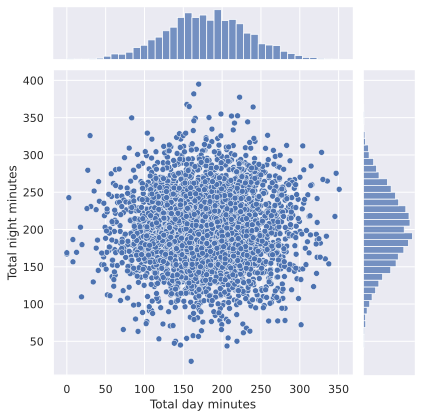

In [ ]:
sns.jointplot(x="Total day minutes", y="Total night minutes", data=df, kind="scatter");


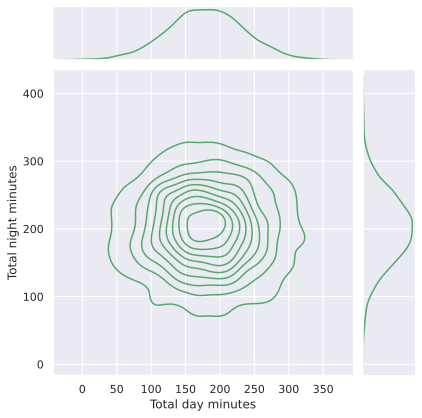

In [ ]:
sns.jointplot(
x="Total day minutes", y="Total night minutes", data=df, kind="kde", color="g"
);

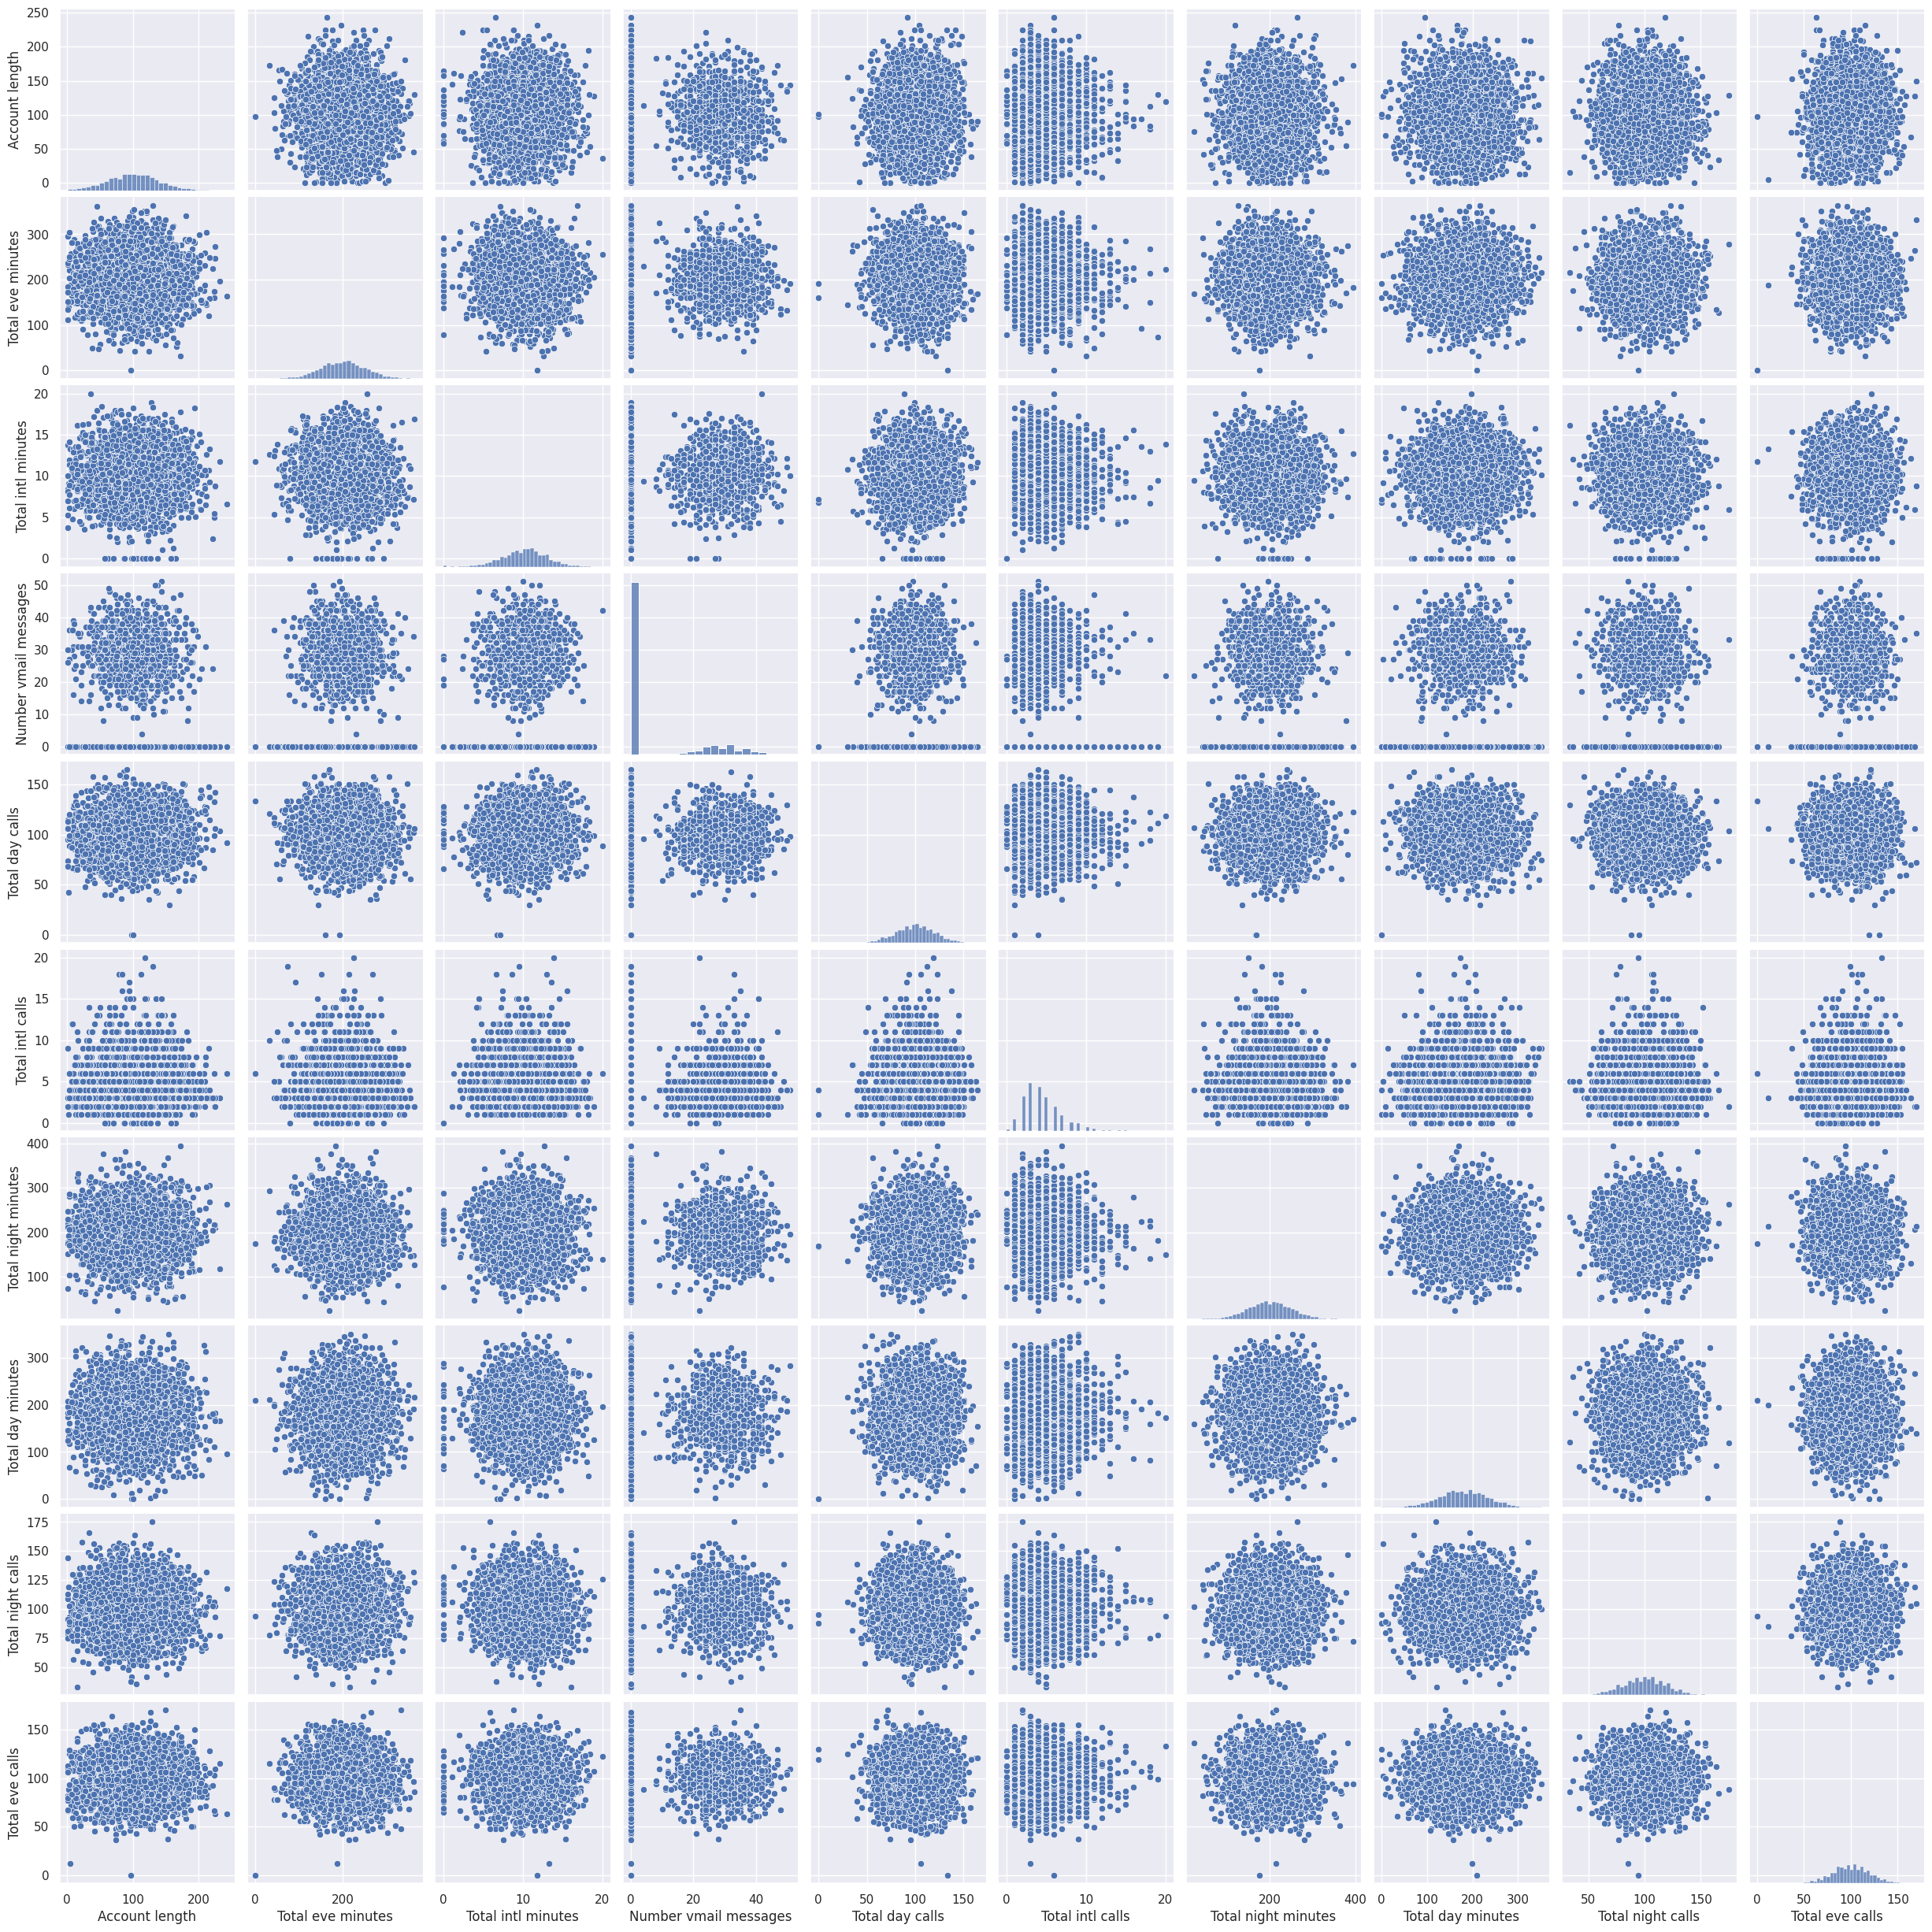

In [ ]:
# `pairplot()` may become very slow with the SVG format
%config InlineBackend.figure_format = 'png'
sns.pairplot(df[numerical]);

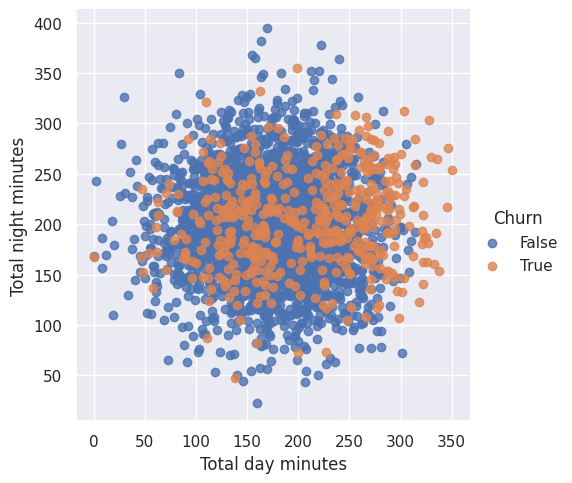

In [ ]:
sns.lmplot(
x="Total day minutes", y="Total night minutes", data=df, hue="Churn", fit_reg=False
);

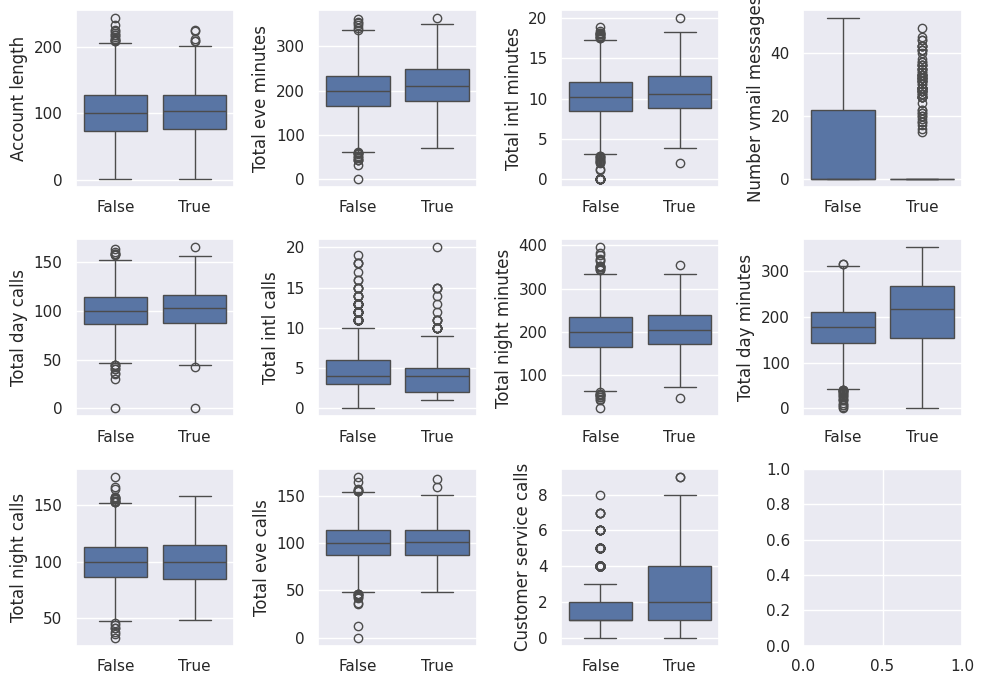

In [ ]:
# Sometimes you can analyze an ordinal variable just as numerical one
numerical.append("Customer service calls")

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 7))
for idx, feat in enumerate(numerical):
  ax = axes[int(idx / 4), idx % 4]
  sns.boxplot(x="Churn", y=feat, data=df, ax=ax)
  ax.set_xlabel("")
  ax.set_ylabel(feat)
fig.tight_layout();

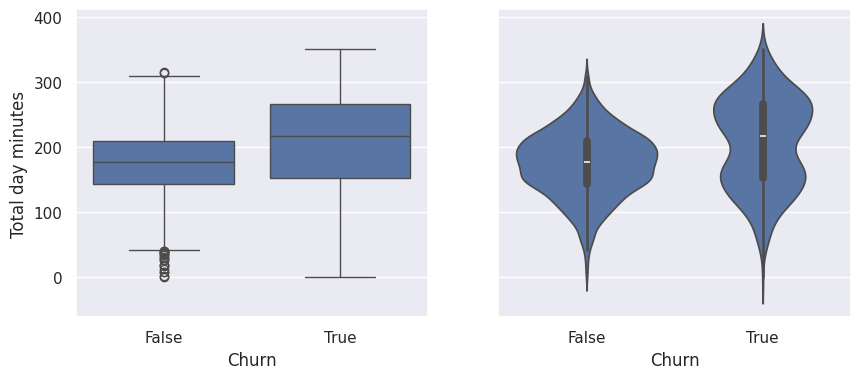

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

sns.boxplot(x="Churn", y="Total day minutes", data=df, ax=axes[0])
sns.violinplot(x="Churn", y="Total day minutes", data=df, ax=axes[1]);

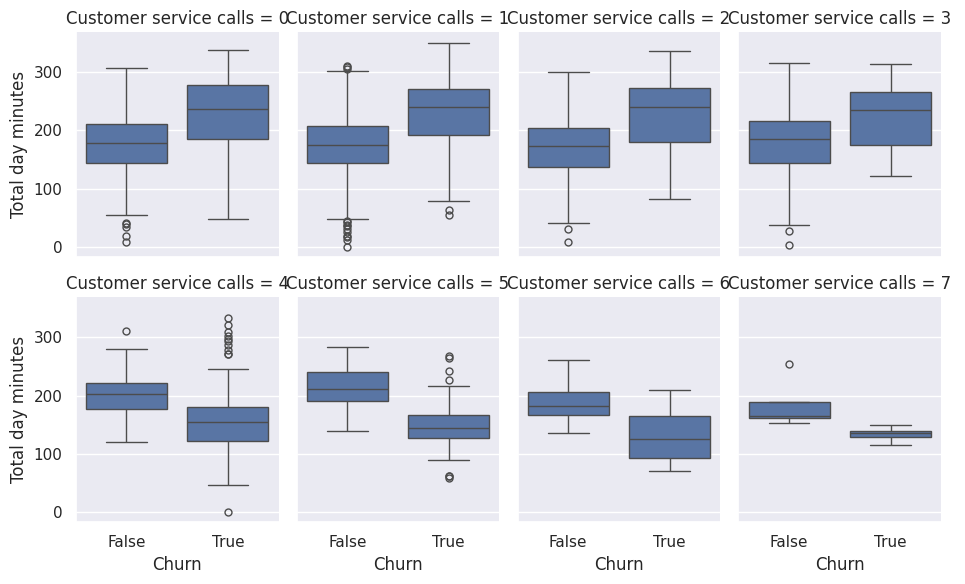

In [ ]:
sns.catplot(
x="Churn",
y="Total day minutes",
col="Customer service calls",
data=df[df["Customer service calls"] < 8],
kind="box",
col_wrap=4,
height=3,
aspect=0.8,
);

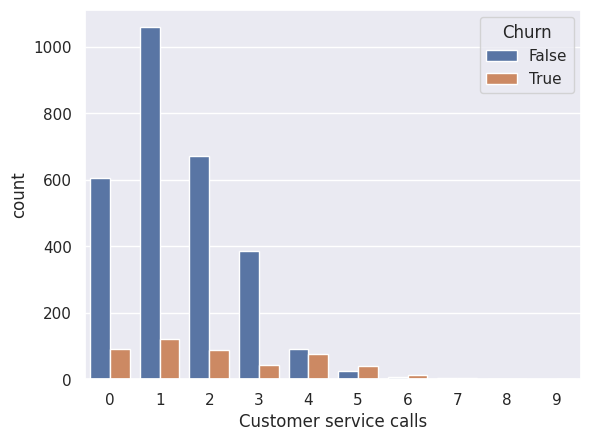

In [ ]:
sns.countplot(x="Customer service calls", hue="Churn", data=df);


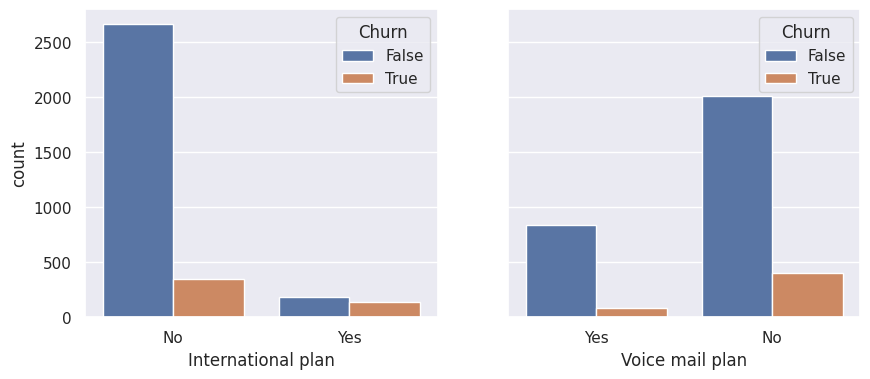

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

sns.countplot(x="International plan", hue="Churn", data=df, ax=axes[0])
sns.countplot(x="Voice mail plan", hue="Churn", data=df, ax=axes[1]);

In [ ]:
pd.crosstab(df["State"], df["Churn"]).T

State,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
Churn,,,,,,,,,,,,,,,,,,,,,
False,49,72,44,60,25,57,62,49,52,55,...,52,48,54,62,72,65,52,71,96,68
True,3,8,11,4,9,9,12,5,9,8,...,8,5,18,10,5,8,14,7,10,9


In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop(["Churn", "State"], axis=1)
X["International plan"] = X["International plan"].map({"Yes": 1, "No": 0})
X["Voice mail plan"] = X["Voice mail plan"].map({"Yes": 1, "No": 0})

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
%%time
tsne = TSNE(random_state=17)
tsne_repr = tsne.fit_transform(X_scaled)

CPU times: user 25.1 s, sys: 54.3 ms, total: 25.2 s
Wall time: 30.3 s


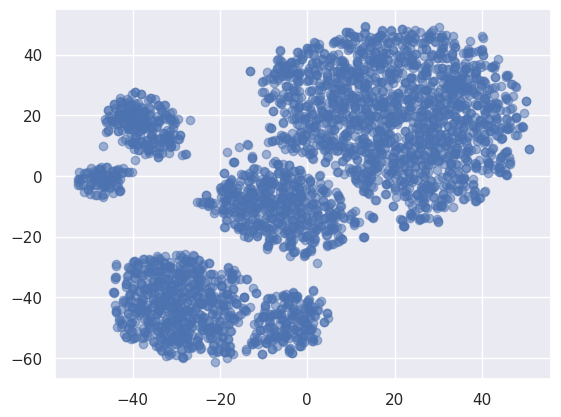

In [ ]:
plt.scatter(tsne_repr[:, 0], tsne_repr[:, 1], alpha=0.5);

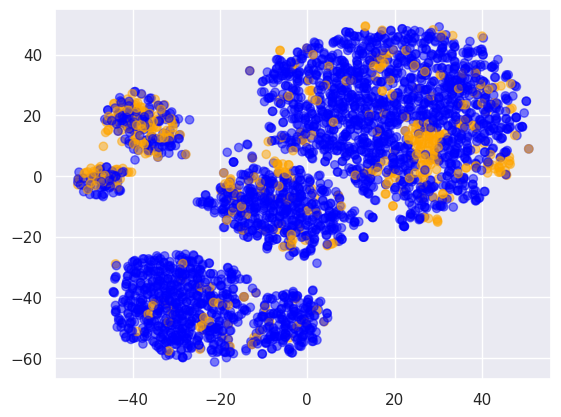

In [ ]:
plt.scatter(
tsne_repr[:, 0],
tsne_repr[:, 1],
c=df["Churn"].map({False: "blue", True: "orange"}),
alpha=0.5,
);

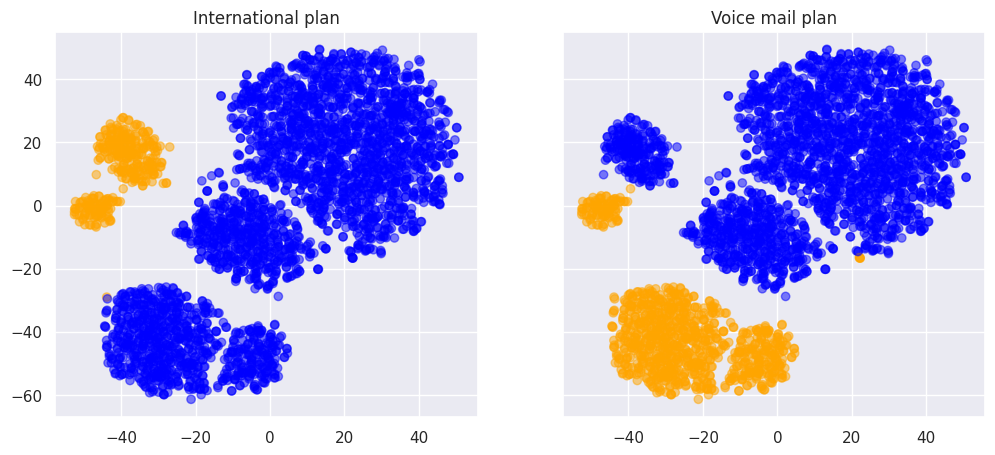

In [ ]:
_, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 5))

for i, name in enumerate(["International plan", "Voice mail plan"]):
  axes[i].scatter(
  tsne_repr[:, 0],
  tsne_repr[:, 1],
  c=df[name].map({"Yes": "orange", "No": "blue"}),
  alpha=0.5,
  )
  axes[i].set_title(name);

In [ ]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"


In [ ]:
df = pd.read_csv(DATA_PATH + "mlbootcamp5_train.csv", sep=";")
print("Dataset size: ", df.shape)
df.head()

Dataset size:  (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


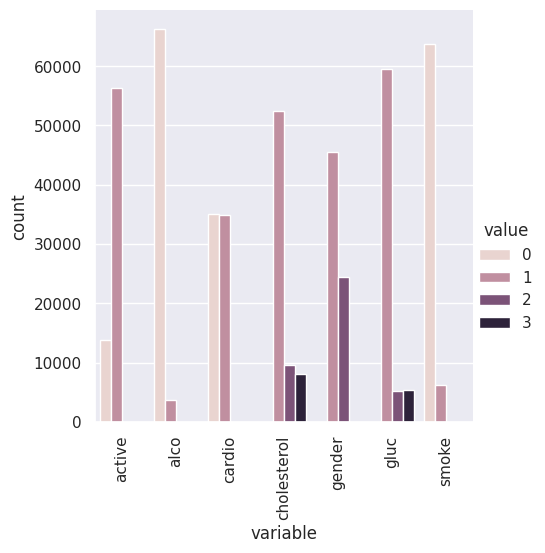

In [ ]:
df_uniques = pd.melt(
frame=df,
value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"],
)
df_uniques = (
pd.DataFrame(df_uniques.groupby(["variable", "value"])["value"].count())
.sort_index(level=[0, 1])
.rename(columns={"value": "count"})
.reset_index()
)

sns.catplot(
x="variable", y="count", hue="value", data=df_uniques, kind="bar"
)
plt.xticks(rotation='vertical');


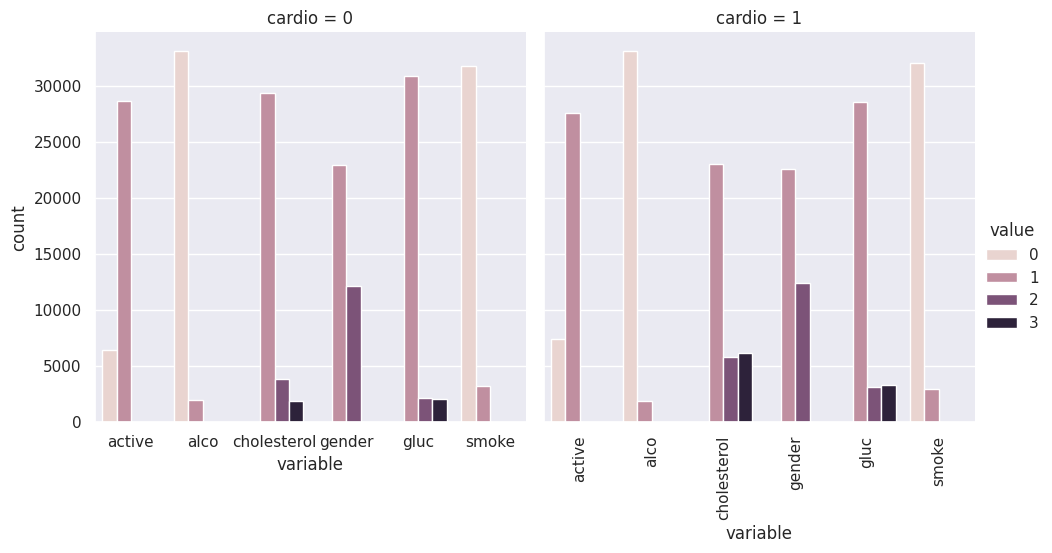

In [ ]:
df_uniques = pd.melt(
frame=df,
value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active"],
id_vars=["cardio"],
)
df_uniques = (
pd.DataFrame(df_uniques.groupby(["variable", "value", "cardio"])["value"].count())
.sort_index(level=[0, 1])
.rename(columns={"value": "count"})
.reset_index()
)

sns.catplot(
x="variable",
y="count",
hue="value",
col="cardio",
data=df_uniques,
kind="bar"
)
plt.xticks(rotation='vertical');

In [ ]:
for c in df.columns:
  n = df[c].nunique()
  print(c)
  if n <= 3:
    print(n, sorted(df[c].value_counts().to_dict().items()))
  else:
    print(n)
    print(10 * "-")

id
70000
----------
age
8076
----------
gender
2 [(1, 45530), (2, 24470)]
height
109
----------
weight
287
----------
ap_hi
153
----------
ap_lo
157
----------
cholesterol
3 [(1, 52385), (2, 9549), (3, 8066)]
gluc
3 [(1, 59479), (2, 5190), (3, 5331)]
smoke
2 [(0, 63831), (1, 6169)]
alco
2 [(0, 66236), (1, 3764)]
active
2 [(0, 13739), (1, 56261)]
cardio
2 [(0, 35021), (1, 34979)]
